# Driver Fare Prediction — Hybrid Stack (fuel-aware)

Two independent pipelines (`one_way`, `round_way`). Target = `Driver Fare`.

**What changed in this version**

| | |
|---|---|
| Fuel price | Fares are adjusted for the Bangladesh pump price in force on the booking date (`FUEL_TABLE`, Stage B). New revisions take effect by adding one row — no retraining. |
| Recency weighting | Available (`RECENCY_HALF_LIFE_DAYS`) but **off by default**: it never helped once fuel was handled. `compare_fuel_strategies()` lets you re-check on your data. |
| Car year | `USE_CAR_YEAR = False` — the production export does not carry it. |
| Export | Writes the bundle **and** a pinned `requirements.txt`; the app checks Python/scikit-learn versions at startup. |

**Before running:** re-apply your own edits from the previous notebook —
the toll figures (`TOLL_TABLE` and region sets, Stage B) and any cleaning
thresholds you tightened (`MIN_*/MAX_*`, `TRIM_LO/TRIM_HI`, Stage A).
This notebook does not contain them.


## 0 · Setup

In [ ]:
!pip -q install lightgbm xgboost catboost cloudpickle

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# ---- point these at your files -------------------------------------------
TRIPS_PATH = "/content/drive/MyDrive/trips_new2.csv"
BIDS_PATH  = "/content/drive/MyDrive/bid_history.xlsx"
# --------------------------------------------------------------------------


## 1 · Place-name standardisation

In [ ]:
"""
STAGE A2 — Place-name standardisation.

The raw district/division columns are badly fragmented: Bengali script,
katakana, pre-2018 spellings (Chittagong/Comilla/Barisal/Bogra/Jessore),
truncations ("Cox's", "Moulvi"), Indian districts from bad geocoding,
upazila names in the district field, and literal "Default ..." placeholders.

Resolution order per row:
  1. exact match after suffix stripping + Bengali/katakana transliteration
  2. normalised-key match  (case/spacing/gonj~ganj insensitive)
  3. fuzzy match against the canonical 64 districts (high cutoff only)
  4. GEOGRAPHIC fallback -- nearest neighbour among rows already resolved
     in steps 1-3, using coordinates
Division is then DERIVED from the resolved district, so a district name can
never appear in the division column and the two can never disagree.
"""
import re
import difflib
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

# ------------------------------------------------------- canonical geography
DISTRICT_TO_DIVISION = {
    # Barishal
    "Barguna": "Barishal", "Barishal": "Barishal", "Bhola": "Barishal",
    "Jhalokati": "Barishal", "Patuakhali": "Barishal", "Pirojpur": "Barishal",
    # Chattogram
    "Bandarban": "Chattogram", "Brahmanbaria": "Chattogram", "Chandpur": "Chattogram",
    "Chattogram": "Chattogram", "Cumilla": "Chattogram", "Cox's Bazar": "Chattogram",
    "Feni": "Chattogram", "Khagrachhari": "Chattogram", "Lakshmipur": "Chattogram",
    "Noakhali": "Chattogram", "Rangamati": "Chattogram",
    # Dhaka
    "Dhaka": "Dhaka", "Faridpur": "Dhaka", "Gazipur": "Dhaka", "Gopalganj": "Dhaka",
    "Kishoreganj": "Dhaka", "Madaripur": "Dhaka", "Manikganj": "Dhaka",
    "Munshiganj": "Dhaka", "Narayanganj": "Dhaka", "Narsingdi": "Dhaka",
    "Rajbari": "Dhaka", "Shariatpur": "Dhaka", "Tangail": "Dhaka",
    # Khulna
    "Bagerhat": "Khulna", "Chuadanga": "Khulna", "Jashore": "Khulna",
    "Jhenaidah": "Khulna", "Khulna": "Khulna", "Kushtia": "Khulna",
    "Magura": "Khulna", "Meherpur": "Khulna", "Narail": "Khulna", "Satkhira": "Khulna",
    # Mymensingh
    "Jamalpur": "Mymensingh", "Mymensingh": "Mymensingh",
    "Netrokona": "Mymensingh", "Sherpur": "Mymensingh",
    # Rajshahi
    "Bogura": "Rajshahi", "Chapai Nawabganj": "Rajshahi", "Joypurhat": "Rajshahi",
    "Naogaon": "Rajshahi", "Natore": "Rajshahi", "Pabna": "Rajshahi",
    "Rajshahi": "Rajshahi", "Sirajganj": "Rajshahi",
    # Rangpur
    "Dinajpur": "Rangpur", "Gaibandha": "Rangpur", "Kurigram": "Rangpur",
    "Lalmonirhat": "Rangpur", "Nilphamari": "Rangpur", "Panchagarh": "Rangpur",
    "Rangpur": "Rangpur", "Thakurgaon": "Rangpur",
    # Sylhet
    "Habiganj": "Sylhet", "Moulvibazar": "Sylhet",
    "Sunamganj": "Sylhet", "Sylhet": "Sylhet",
}
CANON_DISTRICTS = sorted(DISTRICT_TO_DIVISION)
assert len(CANON_DISTRICTS) == 64, len(CANON_DISTRICTS)

# --------------------------------------------------------------- Bengali map
BENGALI = {
    "কক্সবাজার": "Cox's Bazar", "কিশোরগঞ্জ": "Kishoreganj", "কুমিল্লা": "Cumilla",
    "কুষ্টিয়া": "Kushtia", "খুলনা": "Khulna", "গাইবান্ধা": "Gaibandha",
    "গাজীপুর": "Gazipur", "গোপালগঞ্জ": "Gopalganj", "চট্টগ্রাম": "Chattogram",
    "চট্রগ্রাম": "Chattogram", "চাঁদপুর": "Chandpur", "জামালপুর": "Jamalpur",
    "ঝালকাঠি": "Jhalokati", "ঝিনাইদহ": "Jhenaidah", "টাঙ্গাইল": "Tangail",
    "ঠাকুরগাঁও": "Thakurgaon", "ঢাকা": "Dhaka", "দিনাজপুর": "Dinajpur",
    "নওগাঁ": "Naogaon", "নরসিংদী": "Narsingdi", "নাটোর": "Natore",
    "নারায়ণগঞ্জ": "Narayanganj", "নীলফামারী": "Nilphamari", "নেত্রকোনা": "Netrokona",
    "নোয়াখালী": "Noakhali", "পাবনা": "Pabna", "পিরোজপুর": "Pirojpur",
    "ফরিদপুর": "Faridpur", "ফেনী": "Feni", "বগুড়া": "Bogura", "বরগুনা": "Barguna",
    "বরিশাল": "Barishal", "বাগেরহাট": "Bagerhat", "বান্দরবান": "Bandarban",
    "ব্রাহ্মণবাড়িয়া": "Brahmanbaria", "ময়মনসিংহ": "Mymensingh",
    "মাদারীপুর": "Madaripur", "মানিকগঞ্জ": "Manikganj", "মুন্সিগঞ্জ": "Munshiganj",
    "মৌলভীবাজার": "Moulvibazar", "যশোর": "Jashore", "রংপুর": "Rangpur",
    "রাঙামাটি": "Rangamati", "রাজবাড়ী": "Rajbari", "রাজশাহী": "Rajshahi",
    "লক্ষ্মীপুর": "Lakshmipur", "শরিয়তপুর": "Shariatpur", "শেরপুর": "Sherpur",
    "সাতক্ষীরা": "Satkhira", "সিরাজগঞ্জ": "Sirajganj", "সিলেট": "Sylhet",
    "সুনামগঞ্জ": "Sunamganj", "হবিগঞ্জ": "Habiganj",
    "লালমাই": "Cumilla",          # upazila of Cumilla
    "ডাউকি": "Sylhet",
}
KATAKANA = {"ダッカ": "Dhaka", "バリサル": "Barishal", "チッタゴン": "Chattogram"}

# pre-2018 names, truncations, upazilas that appear in the district field
ALIAS = {
    "Chittagong": "Chattogram", "Comilla": "Cumilla", "Cumillla": "Cumilla",
    "Barisal": "Barishal", "Bogra": "Bogura", "Jessore": "Jashore",
    "Jaipurhat": "Joypurhat", "Jhalakathi": "Jhalokati", "Jhalokathi": "Jhalokati",
    "Khagrachari": "Khagrachhari", "Nawabganj": "Chapai Nawabganj",
    "Chapainawabganj": "Chapai Nawabganj", "Netrakona": "Netrokona",
    "Cox's": "Cox's Bazar", "Coxs": "Cox's Bazar", "Cox": "Cox's Bazar",
    "Moulvi": "Moulvibazar", "Maulvibazar": "Moulvibazar", "Sreemongal": "Moulvibazar",
    "Sreemangal": "Moulvibazar", "Srimangal": "Moulvibazar",
    "Bandarban Hill": "Bandarban", "Khagrachari Hill": "Khagrachhari",
    "Rangamati Hill": "Rangamati", "Rangamati Hill Tracts": "Rangamati",
    "Munshigonj": "Munshiganj", "Narshingdi": "Narsingdi", "Shariotpur": "Shariatpur",
    "Mirzapur": "Tangail",       # upazila of Tangail
}

SUFFIXES = [" division", " district", " zila", " jela", " বিভাগ", " জেলা"]
JUNK_TOKENS = {
    "kdc", "rd", "parishad", "riverbank", "upazila", "uddan", "uthrail",
    "uttoralgi", "tamchambridge", "phorushoba", "uttar", "west", "mogbazar",
    "unknown", "nan", "none", "", "select",
}
# non-Bangladesh geography -> never resolvable by name, must go to coordinates
FOREIGN = {
    "ajmer", "burdwan", "jalpaiguri", "north24parganas", "eastkhasihills",
    "jabalpur", "raipur", "presidency", "westbengal", "chhattisgarh",
    "meghalaya", "rajasthan", "tamil", "madhya", "tripura", "assam",
}


def _norm_key(s):
    """Case/space/punctuation-insensitive key with common spelling collapses."""
    s = re.sub(r"[^a-z]", "", str(s).lower())
    return s.replace("gonj", "ganj").replace("gong", "gang")


_CANON_BY_KEY = {_norm_key(c): c for c in CANON_DISTRICTS}
_CANON_BY_KEY.update({_norm_key(k): v for k, v in ALIAS.items()})
_CANON_KEYS = list(_CANON_BY_KEY)


def resolve_name(raw):
    """One name -> canonical district, or None if it needs the geo fallback."""
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return None
    s = str(raw).strip().strip("।").strip(".").strip()
    if not s:
        return None

    # strip administrative suffixes (may be attached in either script)
    low = s.lower()
    for suf in SUFFIXES:
        if low.endswith(suf):
            s = s[: -len(suf)].strip().strip("।").strip()
            low = s.lower()

    if "default" in low:                       # literal placeholder
        return None

    # script transliteration MUST come before the junk check: _norm_key strips
    # every non-Latin character, so a Bengali name would otherwise produce an
    # empty key and be silently classed as junk
    if s in BENGALI:
        return BENGALI[s]
    if s in KATAKANA:
        return KATAKANA[s]
    if re.search(r"[\u0980-\u09FF]", s):       # Bengali but unmapped
        return None
    if re.search(r"[^\x00-\x7F]", s):          # some other script, unmapped
        return None

    k = _norm_key(s)
    if not k or k in JUNK_TOKENS or k in FOREIGN:
        return None
    if k in _CANON_BY_KEY:
        return _CANON_BY_KEY[k]

    # fuzzy, high cutoff only -- a loose cutoff maps junk onto real districts
    hit = difflib.get_close_matches(k, _CANON_KEYS, n=1, cutoff=0.88)
    return _CANON_BY_KEY[hit[0]] if hit else None


class GeoNameFiller:
    """
    Fills unresolved district names from coordinates, using rows whose names
    WERE resolved as the reference set. Fit on training data only.
    """
    def __init__(self):
        self.tree, self.labels = None, None

    def fit(self, lat, lon, district):
        m = pd.notna(district) & pd.notna(lat) & pd.notna(lon)
        pts = np.radians(np.c_[np.asarray(lat)[m], np.asarray(lon)[m]])
        self.tree = BallTree(pts, metric="haversine")
        self.labels = np.asarray(district)[m]
        return self

    def predict(self, lat, lon):
        ok = pd.notna(lat) & pd.notna(lon)
        out = np.array([None] * len(lat), dtype=object)
        if ok.any():
            q = np.radians(np.c_[np.asarray(lat)[ok], np.asarray(lon)[ok]])
            _, idx = self.tree.query(q, k=1)
            out[np.asarray(ok)] = self.labels[idx[:, 0]]
        return out


def standardise_places(df, verbose=True):
    """
    Adds clean pickup_district / pickup_division / dropoff_district /
    dropoff_division plus a `name_source` audit column per endpoint.
    """
    out = df.copy()
    stats = {}

    # one shared filler built from every endpoint that resolved by name
    resolved = {}
    for side, dcol in [("pickup", "Pickup District"), ("dropoff", "Dropoff District")]:
        resolved[side] = out[dcol].map(resolve_name)

    lat = pd.concat([out["Pickup Lat"], out["Dropoff Lat"]], ignore_index=True)
    lon = pd.concat([out["Pickup Long"], out["Dropoff Long"]], ignore_index=True)
    lab = pd.concat([resolved["pickup"], resolved["dropoff"]], ignore_index=True)
    filler = GeoNameFiller().fit(lat, lon, lab)

    for side in ["pickup", "dropoff"]:
        by_name = resolved[side]
        need = by_name.isna()
        geo = pd.Series(filler.predict(out[f"{side.title()} Lat"],
                                       out[f"{side.title()} Long"]), index=out.index)
        final = by_name.where(~need, geo)
        src = np.where(~need, "name", np.where(final.notna(), "geo", "unresolved"))

        out[f"{side}_district"] = final.fillna("Unknown").astype(str)
        # division derived from district -> cannot disagree, cannot hold a district
        out[f"{side}_division"] = (out[f"{side}_district"]
                                   .map(DISTRICT_TO_DIVISION).fillna("Unknown"))
        out[f"{side}_name_source"] = src
        stats[side] = pd.Series(src).value_counts().to_dict()

    if verbose:
        print("place-name standardisation")
        for side in ["pickup", "dropoff"]:
            raw_n = df[f"{side.title()} District"].nunique()
            print(f"  {side:<8} raw distinct: {raw_n:>4}  ->  clean: "
                  f"{out[f'{side}_district'].nunique():>3}   {stats[side]}")
        print(f"  divisions: pickup {out['pickup_division'].nunique()}, "
              f"dropoff {out['dropoff_division'].nunique()} (8 + Unknown expected)")
    return out


## 2 · Stage A — load, clean, audit

Re-apply your own cleaning thresholds here (the `MIN_*`, `MAX_*`, `TRIM_*` constants at the top of the cell).

In [ ]:
"""
STAGE A — Load, clean, audit.
"""
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


DT_FMT = "%B %d, %Y, %I:%M %p"
BD_BOUNDS = dict(lat_min=20.4, lat_max=26.8, lon_min=88.0, lon_max=92.8)

# ---------------------------------------------------------------- car policy
DROP_CAR_TYPES = ["Chander Gari"]
MERGE_SEDAN_ECONOMY = False
MIN_CAR_TYPE_ROWS = 100

TRIM_KM_BANDS = [0, 50, 100, 200, 400, 10 ** 9]
TRIM_KM_LABELS = ["0-50", "50-100", "100-200", "200-400", "400+"]
TRIM_MIN_GROUP = 40          # smaller groups are never trimmed (too few to judge)

# Layer 1 -- LOW-FARE RULE, removed from ALL data.
# A fare below LOW_FARE_RATIO x the median fare-per-km of comparable trips is
# treated as bad data: test bookings, promo/discount rides, mis-keyed fares.
LOW_FARE_RATIO = 0.55

# Layer 2 -- PERCENTILE TRIM, applied to the TRAINING split only (Stage B).
# Rows are flagged here, not dropped, so calibration and test keep every real
# trip and measure what drivers will actually see. Asymmetric on purpose: the
# cheap tail is cut harder, because cheap outliers pull predictions down.
TRIM_LO, TRIM_HI = 0.10, 0.98

MIN_FARE, MAX_FARE = 1000, 60000
MIN_KM, MAX_KM = 5, 2000               # hard rails only, no percentile cut
MIN_FPK, MAX_FPK = 10, 200
MAX_ROUND_DAYS = 20
MIN_CAR_YEAR, MAX_CAR_YEAR = 1985, 2027


def _num(s):
    """'3,508' -> 3508.0"""
    return pd.to_numeric(
        s.astype("string").str.replace(",", "", regex=False).str.strip(),
        errors="coerce")


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def bearing_deg(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dl = np.radians(lon2 - lon1)
    y = np.sin(dl) * np.cos(p2)
    x = np.cos(p1) * np.sin(p2) - np.sin(p1) * np.cos(p2) * np.cos(dl)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360


def load_raw():
    trips = pd.read_csv(TRIPS_PATH)
    bids = pd.read_excel(BIDS_PATH)
    trips.columns = [c.strip() for c in trips.columns]
    bids.columns = [c.strip() for c in bids.columns]
    return trips, bids


def normalise_trips(trips, verbose=True):
    df = trips.copy()

    df["fare"] = _num(df["Driver Fare"])
    df["total_km"] = _num(df["Total Km"])
    df["driver_id"] = _num(df["Driver ID"])

    # raw values include 0, 4, 17, 234, 4587, 275070, 64649494
    cy = pd.to_numeric(df["Driver Car Model Year"], errors="coerce")
    df["car_year"] = cy.where(cy.between(MIN_CAR_YEAR, MAX_CAR_YEAR))

    seats = df["No Of Seat"].astype("string").str.extract(r"(\d+)")[0]
    df["seats"] = pd.to_numeric(seats, errors="coerce")

    for src, dst in [("Pickup Date Time", "pickup_dt"),
                     ("Return Date Time", "return_dt"),
                     ("Created At", "created_dt")]:
        df[dst] = pd.to_datetime(df[src], format=DT_FMT, errors="coerce")

    df["trip_type"] = df["Trip Type"].astype("string").str.strip().str.lower()

    ct = df["Car Type"].astype("string").str.strip()
    if MERGE_SEDAN_ECONOMY:
        ct = ct.replace({"Sedan Economy": "Sedan"})
    df["_drop_car"] = ct.str.lower().isin({c.lower() for c in DROP_CAR_TYPES})
    rare = ct.value_counts()
    keep_level = ct.map(rare).fillna(0) >= MIN_CAR_TYPE_ROWS
    df["car_type"] = ct.where(keep_level | df["_drop_car"], "Other")

    df = standardise_places(df, verbose=verbose)

    df["hav_km"] = haversine_km(df["Pickup Lat"], df["Pickup Long"],
                                df["Dropoff Lat"], df["Dropoff Long"])
    df["fpk"] = df["fare"] / df["total_km"].replace(0, np.nan)
    df["round_days"] = (df["return_dt"] - df["pickup_dt"]).dt.total_seconds() / 86400
    # Trip Status is 100% "Completed" in this extract -> zero information
    return df


def clean(df, verbose=True):
    log, n0 = [], len(df)
    keep = pd.Series(True, index=df.index)

    def drop(mask, label):
        nonlocal keep
        m = keep & mask.fillna(False)
        log.append((label, int(m.sum())))
        keep = keep & ~m

    b = BD_BOUNDS
    drop(df["_drop_car"], f"excluded car type {DROP_CAR_TYPES}")
    drop(df["fare"].isna() | df["total_km"].isna(), "null fare or km")
    drop(df["pickup_dt"].isna() | df["created_dt"].isna(), "unparseable datetime")
    drop(df[["Pickup Lat", "Pickup Long", "Dropoff Lat", "Dropoff Long"]].isna().any(axis=1),
         "null coordinates")
    drop(df["seats"].isna(), "seats not stated")
    drop((df["fare"] <= 0) | (df["total_km"] <= 0), "zero/negative fare or km")
    drop((df["fare"] < MIN_FARE) | (df["fare"] > MAX_FARE), f"fare outside {MIN_FARE}-{MAX_FARE}")
    drop((df["total_km"] < MIN_KM) | (df["total_km"] > MAX_KM), f"km outside {MIN_KM}-{MAX_KM}")
    drop((df["fpk"] < MIN_FPK) | (df["fpk"] > MAX_FPK), f"fare/km outside {MIN_FPK}-{MAX_FPK}")
    for col, lo, hi in [("Pickup Lat", b["lat_min"], b["lat_max"]),
                        ("Dropoff Lat", b["lat_min"], b["lat_max"]),
                        ("Pickup Long", b["lon_min"], b["lon_max"]),
                        ("Dropoff Long", b["lon_min"], b["lon_max"])]:
        drop((df[col] < lo) | (df[col] > hi), f"{col} outside Bangladesh")
    drop((df["Pickup Lat"] == df["Dropoff Lat"]) & (df["Pickup Long"] == df["Dropoff Long"]),
         "pickup == dropoff coordinates")
    drop(df["hav_km"] < 0.5, "endpoints < 500m apart")
    drop(df["total_km"] < 0.95 * df["hav_km"], "total_km below straight-line distance")
    drop(df["total_km"] > 6 * df["hav_km"].clip(lower=1),
         "total_km implausibly long vs straight line")
    rw = df["trip_type"].eq("round_way")
    drop(rw & (df["round_days"].isna() | (df["round_days"] < 0)),
         "round trip: missing/negative return time")
    drop(rw & (df["round_days"] > MAX_ROUND_DAYS), f"round trip longer than {MAX_ROUND_DAYS} days")
    drop(~rw & df["return_dt"].notna(), "one-way with a return time")
    drop((df["pickup_dt"] - df["created_dt"]).dt.total_seconds() < -3600,
         "pickup more than 1h before booking")
    drop((df["pickup_district"] == "Unknown") | (df["dropoff_district"] == "Unknown"),
         "location not resolvable to a district")
    drop(df["Booking ID"].duplicated(keep="first"), "duplicate booking id")

    out = df[keep].copy()
    n1 = len(out)

    # ---- compare each fare with trips like it
    out["_band"] = pd.cut(out["total_km"], TRIM_KM_BANDS, labels=TRIM_KM_LABELS)
    keys = ["trip_type", "car_type", "_band"]
    grp = out.groupby(keys, observed=True)["fpk"]
    size = grp.transform("size")
    judged = size >= TRIM_MIN_GROUP
    ratio = out["fpk"] / grp.transform("median")

    # layer 1: implausibly cheap for its trip -> removed everywhere
    before = len(out)
    low = judged & (ratio < LOW_FARE_RATIO)
    out = out[~low].copy()
    log.append((f"fare below {LOW_FARE_RATIO:.0%} of comparable trips' median "
                f"fare/km (all data)", before - len(out)))

    # layer 2: flag the tails for training-only removal (recomputed after layer 1)
    grp = out.groupby(keys, observed=True)["fpk"]
    size = grp.transform("size")
    lo = grp.transform(lambda v: v.quantile(TRIM_LO))
    hi = grp.transform(lambda v: v.quantile(TRIM_HI))
    out["train_trim"] = (size >= TRIM_MIN_GROUP) & ~out["fpk"].between(lo, hi)
    out = out.drop(columns="_band")

    if verbose:
        print(f"raw rows: {n0:,}")
        print("-" * 66)
        for label, n in log:
            if n:
                print(f"  -{n:>5,}  {label}")
        print("-" * 66)
        print(f"after rules:  {n1:,}   ({n1/n0:.1%} kept)")
        print(f"after low-fare rule: {len(out):,}   ({len(out)/n0:.1%} kept)")
        ft = out["train_trim"]
        print(f"flagged for TRAINING-only trim ({TRIM_LO:.0%} low / {1-TRIM_HI:.0%} high "
              f"fare/km within trip type x car type x distance band): {ft.sum():,} "
              f"({ft.mean():.1%}) -- kept for calibration/test")
        band = pd.cut(out["total_km"], TRIM_KM_BANDS, labels=TRIM_KM_LABELS)
        print((out.groupby(["trip_type", band], observed=True)["train_trim"].mean() * 100)
              .round(1).unstack().to_string())
        print()
        print(out.groupby("trip_type").agg(
            n=("fare", "size"), fare_med=("fare", "median"),
            km_med=("total_km", "median"), km_max=("total_km", "max"),
            fpk_med=("fpk", "median")).round(1).to_string())
        print()
        print(pd.crosstab(out["car_type"], out["trip_type"]).to_string())
        assert "Other" not in set(out["car_type"]), "an 'Other' bucket survived"
    return out.drop(columns=["_drop_car"]).reset_index(drop=True)


def reconcile_target(trips_clean, bids):
    """Sanity check only: does Driver Fare agree with the accepted bid?"""
    acc = (bids.groupby("Booking ID")
                .agg(accept_fare=("Accept Driver Fare", "first"),
                     n_bids=("Driver Bid", "size")).reset_index())
    m = trips_clean[["Booking ID", "fare"]].merge(acc, on="Booking ID", how="left")
    has = m["accept_fare"].notna()
    print(f"trips with bid history : {has.mean():.1%}")
    print(f"fare == accepted bid   : {(m.loc[has,'fare'] == m.loc[has,'accept_fare']).mean():.1%}")
    return m


In [ ]:
trips_raw, bids_raw = load_raw()
trips_norm = normalise_trips(trips_raw)
clean_df   = clean(trips_norm)
print()
_ = reconcile_target(clean_df, bids_raw)


place-name standardisation
  pickup   raw distinct:  126  ->  clean:  63   {'name': 16450, 'geo': 37}
  dropoff  raw distinct:  158  ->  clean:  64   {'name': 16397, 'geo': 90}
  divisions: pickup 8, dropoff 8 (8 + Unknown expected)
raw rows: 16,487
------------------------------------------------------------------
  -   65  fare outside 1000-60000
  -   22  km outside 5-2000
  -   37  fare/km outside 10-200
  -    3  pickup == dropoff coordinates
  -    2  endpoints < 500m apart
  -   20  total_km implausibly long vs straight line
  -    5  round trip: missing/negative return time
  -   15  pickup more than 1h before booking
  -   20  fare below 55% of comparable trips' median fare/km (all data)
------------------------------------------------------------------
after rules:  16,318   (99.0% kept)
after low-fare rule: 16,298   (98.9% kept)
flagged for TRAINING-only trim (10% low / 2% high fare/km within trip type x car type x distance band): 1,954 (12.0%) -- kept for calibration/test
t

## 3 · Stage B — features, fuel adjustment, chronological split

**Fuel.** A fare is fuel cost plus everything else. When pump prices move by a
ratio *r*, only the fuel part moves, so the fare moves by `1 + s·(r − 1)`,
where *s* is fuel's share of the fare (≈0.22–0.34 by car type, from km/litre
and median fare per km). Training fares are divided by that factor and every
prediction is multiplied back by it for the booking date's price.

Why not simply feed fuel price to the models as a feature: tree models cannot
extrapolate. A GBM that never saw Tk 160 treats it exactly like the highest
price in training. The multiplicative adjustment scales to any price.

**Update `FUEL_TABLE` whenever the government revises prices.** If your data
starts before Nov 2025, add the earlier months too — rows before the first
entry are assumed to carry the first price.

Re-apply your toll edits here too (`TOLL_TABLE`, region sets).

In [ ]:
"""
STAGE B — Features + chronological split.

Hard rule: every feature must be computable at BID time from
  car_type, seats, trip_type, pickup/dropoff coords, total_km,
  pickup datetime, booking datetime, and (round trips) return datetime.

Three domain feature blocks, each validated against the data:
  FESTIVAL  median fare jumps 3,500 -> 5,100 in the 3 days before Eid
  TOLL      Padma-crossing routes run +26% per km at matched distance
  BACKHAUL  remote destinations pay more; +3.7pp within-10% on round trips
"""
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold


RANDOM_STATE = 42
N_CLUSTERS = 40
SMOOTH = 20

# `car_year` is the WINNING driver's car model year. Legitimate when suggesting
# to a specific driver (they know their own car); leakage if your bid screen
# does not have it. Set False in that case.
USE_CAR_YEAR = False

DHAKA = (23.8103, 90.4125)

# ====================================================================== FESTIVAL
# Bangladesh observance dates. Eid shifts ~11 days earlier each year, so a
# month flag does not generalise forward -- day distance to the actual date does.
EID_FITR = ["2024-04-11", "2025-03-31", "2026-03-20", "2027-03-10", "2028-02-27"]
EID_ADHA = ["2024-06-17", "2025-06-07", "2026-05-27", "2027-05-17", "2028-05-05"]
DURGA_PUJA = ["2024-10-13", "2025-10-02", "2026-10-20", "2027-10-09", "2028-09-28"]
BOISHAKH = [f"{y}-04-14" for y in range(2024, 2029)]

_EID_ALL = np.array(pd.to_datetime(EID_FITR + EID_ADHA), dtype="datetime64[D]")
_IS_ADHA = np.array([0] * len(EID_FITR) + [1] * len(EID_ADHA))
_FEST_ALL = np.array(pd.to_datetime(EID_FITR + EID_ADHA + DURGA_PUJA + BOISHAKH),
                     dtype="datetime64[D]")


def _signed_days_to_nearest(dates, targets):
    d = np.asarray(dates.values, dtype="datetime64[D]")
    diff = (d[:, None] - targets[None, :]).astype("timedelta64[D]").astype(float)
    j = np.argmin(np.abs(diff), axis=1)
    return diff[np.arange(len(d)), j], j


def add_festival_features(df):
    """
    Measured shape of the Eid effect (median fare/km, baseline 33.5):
        -21..-7 days  31.9   pre-Eid lull
         -7..-3 days  36.7
         -3.. 0 days  41.4   peak
          0.. 3 days  38.5
          3.. 7 days  38.1   return leg
          7..14 days  35.7
    """
    d = df
    sd, j = _signed_days_to_nearest(d["pickup_dt"].dt.normalize(), _EID_ALL)
    d["d2eid"] = np.clip(sd, -45, 45)
    d["abs_d2eid"] = np.abs(d["d2eid"])
    d["is_adha"] = _IS_ADHA[j]
    d["eid_peak"] = ((sd >= -3) & (sd <= 0)).astype(int)
    d["eid_rush"] = ((sd >= -7) & (sd <= 0)).astype(int)
    d["eid_return"] = ((sd > 0) & (sd <= 7)).astype(int)
    d["eid_week"] = (np.abs(sd) <= 7).astype(int)
    d["eid_extended"] = (np.abs(sd) <= 14).astype(int)
    d["eid_lull"] = ((sd >= -21) & (sd < -7)).astype(int)
    d["adha_rush"] = d["eid_rush"] * d["is_adha"]     # Adha is the stronger peak

    sf, _ = _signed_days_to_nearest(d["pickup_dt"].dt.normalize(), _FEST_ALL)
    d["d2festival"] = np.clip(sf, -45, 45)
    d["abs_d2festival"] = np.abs(d["d2festival"])
    d["festival_week"] = (np.abs(sf) <= 7).astype(int)
    return d


FESTIVAL_NUM = ["d2eid", "abs_d2eid", "is_adha", "eid_peak", "eid_rush",
                "eid_return", "eid_week", "eid_extended", "eid_lull",
                "adha_rush", "d2festival", "abs_d2festival", "festival_week"]


def festival_month_audit(df, min_n=30):
    """
    Data-driven cross-check: which months actually ran hot, and did an Eid fall
    in them? Use this to confirm the calendar above matches your market.
    """
    d = df[df["total_km"] > 5].copy()
    d["ym"] = d["pickup_dt"].dt.to_period("M")
    m = d.groupby("ym").agg(n=("fpk", "size"), median_fpk=("fpk", "median"))
    m = m[m["n"] >= min_n]
    base = m["median_fpk"].rolling(7, center=True, min_periods=3).median()
    m["vs_baseline"] = (m["median_fpk"] / base).round(3)
    eid_months = {pd.Period(x, "M") for x in EID_FITR + EID_ADHA}
    m["eid_month"] = [p in eid_months for p in m.index]
    m["hot"] = m["vs_baseline"] > 1.03
    return m.round(2)


# ========================================================================= TOLL
# Bangladesh's major toll barriers. Crossing one materially changes fare/km:
# distance-controlled, Padma routes bill +26% per km vs non-Padma.
PADMA_SIDE = {
    "Barguna", "Barishal", "Bhola", "Jhalokati", "Patuakhali", "Pirojpur",
    "Bagerhat", "Chuadanga", "Jashore", "Jhenaidah", "Khulna", "Kushtia",
    "Magura", "Meherpur", "Narail", "Satkhira",
    "Madaripur", "Shariatpur", "Gopalganj", "Faridpur", "Rajbari",
}
JAMUNA_SIDE = {
    "Bogura", "Chapai Nawabganj", "Joypurhat", "Naogaon", "Natore", "Pabna",
    "Rajshahi", "Sirajganj",
    "Dinajpur", "Gaibandha", "Kurigram", "Lalmonirhat", "Nilphamari",
    "Panchagarh", "Rangpur", "Thakurgaon",
}
MEGHNA_SIDE = {
    "Bandarban", "Brahmanbaria", "Chandpur", "Chattogram", "Cumilla",
    "Cox's Bazar", "Feni", "Khagrachhari", "Lakshmipur", "Noakhali", "Rangamati",
}
SYLHET_SIDE = {"Habiganj", "Moulvibazar", "Sunamganj", "Sylhet"}

# approximate published one-way tolls in BDT per vehicle class
TOLL_TABLE = {
    "PADMA":  {"car": 750, "microbus": 1300, "minibus": 1400},
    "JAMUNA": {"car": 500, "microbus": 600, "minibus": 750},
    "MEGHNA": {"car": 200, "microbus": 300, "minibus": 400},
    "SYLHET": {"car": 100, "microbus": 150, "minibus": 200},
}
VEHICLE_CLASS = {
    "Sedan": "car", "Sedan Premium": "car", "Sedan Economy": "car",
    "Noah": "microbus", "HiAce": "minibus",
}


def _region(district):
    if district in PADMA_SIDE:
        return "PADMA"
    if district in JAMUNA_SIDE:
        return "JAMUNA"
    if district in MEGHNA_SIDE:
        return "MEGHNA"
    if district in SYLHET_SIDE:
        return "SYLHET"
    return "CENTRAL"


def add_toll_features(df):
    """
    Barriers on a route are inferred from which side of the country each end
    sits on. Approximation: a route between two non-central regions is assumed
    to cross both barriers, which slightly overstates rare lateral routes
    (e.g. Khulna->Rajshahi). Toll amounts are published figures; the model fits
    its own coefficient, so relative ordering matters more than the exact level.
    """
    d = df
    pu_r = d["pickup_district"].map(_region)
    do_r = d["dropoff_district"].map(_region)
    d["pu_region"], d["do_region"] = pu_r, do_r

    diff = pu_r != do_r
    barriers = []
    for a, b, differs in zip(pu_r, do_r, diff):
        if not differs:
            barriers.append(frozenset())
        else:
            barriers.append(frozenset({r for r in (a, b) if r != "CENTRAL"}))

    veh = d["car_type"].map(VEHICLE_CLASS).fillna("car")
    toll = np.array([
        sum(TOLL_TABLE[bar][v] for bar in bs) for bs, v in zip(barriers, veh)
    ], dtype=float)
    mult = np.where(d["trip_type"].eq("round_way"), 2.0, 1.0)   # tolls both ways

    d["crosses_padma"] = [int("PADMA" in bs) for bs in barriers]
    d["crosses_jamuna"] = [int("JAMUNA" in bs) for bs in barriers]
    d["crosses_meghna"] = [int("MEGHNA" in bs) for bs in barriers]
    d["crosses_sylhet"] = [int("SYLHET" in bs) for bs in barriers]
    d["n_barriers"] = [len(bs) for bs in barriers]
    d["est_toll_bdt"] = toll * mult
    d["toll_per_km"] = d["est_toll_bdt"] / d["total_km"].clip(lower=1)
    d["log_toll"] = np.log1p(d["est_toll_bdt"])
    d["same_region"] = (~diff).astype(int)

    # undirected route key: Dhaka->Khulna and Khulna->Dhaka share toll economics,
    # which doubles the sample size behind each route encoding
    a = d["pickup_district"].astype(str)
    b = d["dropoff_district"].astype(str)
    d["route_und"] = np.where(a < b, a + "|" + b, b + "|" + a)
    d["region_pair"] = pu_r.astype(str) + ">" + do_r.astype(str)
    return d


TOLL_NUM = ["crosses_padma", "crosses_jamuna", "crosses_meghna", "crosses_sylhet",
            "n_barriers", "est_toll_bdt", "toll_per_km", "log_toll", "same_region"]


# ===================================================================== BACKHAUL
BACKHAUL_NUM = ["do_dist_dhaka", "pu_dist_dhaka", "net_toward_dhaka",
                "to_dhaka", "from_dhaka", "do_origin_share", "do_term_share",
                "log_backhaul_ratio"]


class BackhaulStats:
    """Destination-remoteness counts. Fitted on TRAIN rows only."""
    def fit(self, train):
        self.orig = train["pickup_district"].value_counts()
        self.term = train["dropoff_district"].value_counts()
        self.tot = len(train)
        return self

    def transform(self, d):
        d["do_dist_dhaka"] = haversine_km(d["dropoff_lat"], d["dropoff_long"], *DHAKA)
        d["pu_dist_dhaka"] = haversine_km(d["pickup_lat"], d["pickup_long"], *DHAKA)
        d["net_toward_dhaka"] = d["pu_dist_dhaka"] - d["do_dist_dhaka"]
        d["to_dhaka"] = (d["dropoff_district"] == "Dhaka").astype(int)
        d["from_dhaka"] = (d["pickup_district"] == "Dhaka").astype(int)
        d["do_origin_share"] = d["dropoff_district"].map(self.orig).fillna(0) / self.tot
        d["do_term_share"] = d["dropoff_district"].map(self.term).fillna(0) / self.tot
        d["log_backhaul_ratio"] = np.log(
            (d["dropoff_district"].map(self.orig).fillna(0) + 5) /
            (d["dropoff_district"].map(self.term).fillna(0) + 5))
        return d


# ======================================================================= CORE
BASE_NUM = [
    "total_km", "log_km", "hav_km", "road_factor", "seats", "car_year",
    "pickup_lat", "pickup_long", "dropoff_lat", "dropoff_long",
    "bearing", "lat_delta", "long_delta",
    "hour", "dow", "month", "is_weekend", "is_night",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "lead_hours", "log_lead_hours", "is_same_day",
    "same_district", "same_division",
]
# round_days removed: |r| = 1.000 with round_hours
ROUND_NUM = ["round_hours", "km_per_day", "is_multiday", "km_per_hour"]

CATS = ["car_type", "pickup_division", "pickup_district",
        "dropoff_division", "dropoff_district", "pu_zone", "do_zone",
        "zone_pair", "route_und", "region_pair"]

ENC_KEYS = {
    "enc_route_und": ["route_und"],
    "enc_route_und_car": ["route_und", "car_type"],
    "enc_dist_pair": ["pickup_district", "dropoff_district"],
    "enc_dist_pair_car": ["pickup_district", "dropoff_district", "car_type"],
    "enc_div_pair_car": ["pickup_division", "dropoff_division", "car_type"],
    "enc_zone_pair_car": ["pu_zone", "do_zone", "car_type"],
    "enc_region_pair_car": ["region_pair", "car_type"],
    "enc_pu_district": ["pickup_district"],
    "enc_do_district": ["dropoff_district"],
}



# ========================================================================= FUEL
# Bangladesh pump prices, Tk per litre. Each row is the price in force FROM that
# date until the next row. When the government revises prices, append a row --
# nothing else needs to change. Keep rows in date order.
#             effective_from  diesel octane petrol kerosene
FUEL_TABLE = [
    ("2025-11-01",            102,   122,   118,   114),
    ("2025-12-01",            104,   124,   120,   116),
    ("2026-01-01",            102,   122,   118,   114),
    ("2026-02-01",            100,   120,   116,   112),
    ("2026-04-19",            115,   140,   135,   130),
    ("2026-06-01",            115,   145,   140,   135),
    ("2026-09-21",            135,   165,   160,   155),
]
# Trips booked BEFORE the first row are assumed to carry that first price.
# If your data starts earlier, add the earlier months above for best accuracy.

# The fleet runs on octane or petrol, so the relevant price is the average of
# the two. Map a car type to "diesel" / "octane" / "petrol" to override.
FUEL_GRADE_BY_CAR = {}              # e.g. {"HiAce": "diesel"}
DEFAULT_FUEL_GRADE = "petrol_octane"

# Rough highway economy (km per litre). Only used to estimate what SHARE of a
# fare is fuel. A 20% error here changes the fuel adjustment by ~20% of itself,
# i.e. well under 1% of the fare. Edit if you know your fleet better.
KM_PER_LITRE = {"Sedan": 11, "Sedan Premium": 12, "Sedan Economy": 14,
                "Noah": 14, "HiAce": 8}
DEFAULT_KM_PER_LITRE = 11

FUEL_MODE = "cost_share"            # "cost_share" = adjust for fuel | "off"
COST_SHARE_BOUNDS = (0.10, 0.60)    # sanity rails on fuel's share of a fare

# How much of a fuel-cost change actually reaches the fare. 1.0 = passed on in
# full. Run compare_fuel_strategies() (Stage C) on your data before changing:
# on the Aug-2026 extract one-way looked like ~0.5-0.75 and round trips ~1.0,
# but that was read off the test slice, so treat it as a hint, not a setting.
FUEL_PASSTHROUGH = {"one_way": 1.0, "round_way": 1.0}

# Recency weighting: a trip's weight halves every N days of age. OFF by default
# because on the Aug-2026 extract it never helped (and cost round trips ~3% MAE)
# once fuel was handled -- the drift it was meant to catch was mostly fuel.
RECENCY_HALF_LIFE_DAYS = None

_GRADE_COL = {"diesel": 0, "octane": 1, "petrol": 2, "kerosene": 3}


def fuel_price_at(dates, car_types=None, table=None):
    """Pump price (Tk/L) in force on each date for each car's fuel grade.
    Returns (price, backfilled) where backfilled marks dates before the table."""
    table = table or FUEL_TABLE
    starts = np.array(pd.to_datetime([r[0] for r in table]), dtype="datetime64[ns]")
    d = np.asarray(pd.to_datetime(pd.Series(dates)), dtype="datetime64[ns]")
    idx = np.searchsorted(starts, d, side="right") - 1
    before = idx < 0
    idx = np.clip(idx, 0, len(table) - 1)
    arr = np.array([r[1:] for r in table], dtype=float)
    if car_types is None:
        grades = np.full(len(d), DEFAULT_FUEL_GRADE, dtype=object)
    else:
        grades = (pd.Series(list(car_types)).map(FUEL_GRADE_BY_CAR)
                  .fillna(DEFAULT_FUEL_GRADE).to_numpy(dtype=object))
    price = np.empty(len(d), dtype=float)
    for g in pd.unique(grades):
        m = grades == g
        if g == "petrol_octane":
            price[m] = (arr[idx[m], 1] + arr[idx[m], 2]) / 2.0
        else:
            price[m] = arr[idx[m], _GRADE_COL[g]]
    return price, before


class FuelAdjuster:
    """
    Puts every historical fare on the same fuel footing.

    A fare = fuel cost + everything else (driver time, wear, margin). When pump
    prices move by a ratio r, only the fuel part moves, so the fare moves by
    (1 + s * (r - 1)), where s is fuel's share of the fare. s is estimated per
    car type from km/litre and the median fare per km in training.

    Training targets are DIVIDED by that factor (deflated to one reference
    price) and every prediction is MULTIPLIED back by the factor for the price
    in force on the booking date. The models therefore learn "real" fares, and
    the fuel level is applied last, explicitly.

    Why not simply add fuel price as a feature: tree models cannot extrapolate.
    A GBM that never saw Tk 160 treats it exactly like the highest price in
    training. A multiplicative adjustment scales correctly to any price, and
    it is how a new price revision takes effect without retraining.
    """
    def __init__(self, mode=None, passthrough=1.0):
        self.mode = mode or FUEL_MODE
        self.passthrough = float(passthrough)

    def fit(self, train):
        self.ref = float(np.median(train["fuel_price"]))
        lo, hi = COST_SHARE_BOUNDS
        med = train.groupby("car_type")["fpk"].median()
        self.share = {}
        for car, fpk in med.items():
            if fpk and fpk > 0:
                kmpl = KM_PER_LITRE.get(car, DEFAULT_KM_PER_LITRE)
                self.share[car] = float(np.clip((self.ref / kmpl) / fpk, lo, hi))
        self.default_share = (float(np.median(list(self.share.values())))
                              if self.share else 0.30)
        return self

    def log_factor(self, df):
        if self.mode == "off":
            return np.zeros(len(df))
        s = df["car_type"].map(self.share).fillna(self.default_share).to_numpy(float)
        r = df["fuel_price"].to_numpy(float) / self.ref
        return np.log1p(self.passthrough * s * (r - 1.0))

    def transform(self, df):
        df = df.copy()
        a = self.log_factor(df)
        df["fuel_adj"] = a
        for col in ("log_y", "log_fpk"):
            if col in df:
                df[col] = df[col] - a
        return df

    def describe(self):
        return {"mode": self.mode, "reference_price": round(self.ref, 1),
                "passthrough": self.passthrough,
                "fuel_share_by_car": {k: round(v, 3) for k, v in self.share.items()}}


def recency_weights(train, half_life):
    """Weight halves every `half_life` days of age; normalised to mean 1."""
    if not half_life:
        return np.ones(len(train))
    age = (train["created_dt"].max() - train["created_dt"]).dt.days.to_numpy(float)
    w = 0.5 ** (age / float(half_life))
    return w / w.mean()


def fuel_audit(df, min_n=30):
    """Monthly fare per km, raw vs fuel-adjusted, next to the pump price.
    If the adjustment works, the adjusted column is flatter than the raw one."""
    d = df[df["total_km"] > 5].copy()
    if "fuel_price" not in d:
        d["fuel_price"], _ = fuel_price_at(d["created_dt"], d["car_type"])
    d["m"] = d["created_dt"].dt.to_period("M")
    t = d.groupby("m").agg(n=("fpk", "size"), fuel_price=("fuel_price", "median"),
                           raw_fpk=("fpk", "median"))
    if "fuel_adj" in d:
        d["adj_fpk"] = d["fpk"] / np.exp(d["fuel_adj"])
        t["adjusted_fpk"] = d.groupby("m")["adj_fpk"].median()
    return t[t["n"] >= min_n].round(2)


def build_base_features(df):
    out = df.copy().rename(columns={
        "Pickup Lat": "pickup_lat", "Pickup Long": "pickup_long",
        "Dropoff Lat": "dropoff_lat", "Dropoff Long": "dropoff_long"})

    out["log_km"] = np.log1p(out["total_km"])
    out["road_factor"] = out["total_km"] / out["hav_km"].clip(lower=0.5)
    out["bearing"] = bearing_deg(out["pickup_lat"], out["pickup_long"],
                                 out["dropoff_lat"], out["dropoff_long"])
    out["lat_delta"] = out["dropoff_lat"] - out["pickup_lat"]
    out["long_delta"] = out["dropoff_long"] - out["pickup_long"]

    pdt = out["pickup_dt"]
    out["hour"] = pdt.dt.hour
    out["dow"] = pdt.dt.dayofweek
    out["month"] = pdt.dt.month
    out["is_weekend"] = out["dow"].isin([4, 5]).astype(int)      # Fri/Sat in BD
    out["is_night"] = out["hour"].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
    for col, period in [("hour", 24), ("dow", 7), ("month", 12)]:
        out[f"{col}_sin"] = np.sin(2 * np.pi * out[col] / period)
        out[f"{col}_cos"] = np.cos(2 * np.pi * out[col] / period)

    out["lead_hours"] = ((pdt - out["created_dt"]).dt.total_seconds() / 3600).clip(0, 24 * 60)
    out["log_lead_hours"] = np.log1p(out["lead_hours"])
    out["is_same_day"] = (pdt.dt.date == out["created_dt"].dt.date).astype(int)

    out["same_district"] = (out["pickup_district"] == out["dropoff_district"]).astype(int)
    out["same_division"] = (out["pickup_division"] == out["dropoff_division"]).astype(int)

    out["round_hours"] = (out["return_dt"] - pdt).dt.total_seconds() / 3600
    out["km_per_day"] = out["total_km"] / (out["round_hours"] / 24).clip(lower=0.25)
    out["km_per_hour"] = out["total_km"] / out["round_hours"].clip(lower=1)
    out["is_multiday"] = (out["round_hours"] > 24).astype(int)

    out = add_festival_features(out)
    out = add_toll_features(out)

    # fuel price in force when the fare was agreed (booking time). An explicit
    # override (scenario testing, or a price not yet in FUEL_TABLE) wins.
    price, before = fuel_price_at(out["created_dt"], out["car_type"])
    if "fuel_price_override" in out.columns:
        ov = pd.to_numeric(out["fuel_price_override"], errors="coerce").to_numpy(float)
        use = np.isfinite(ov) & (ov > 0)
        price = np.where(use, ov, price)
        before = np.where(use, False, before)
    out["fuel_price"] = price
    out["fuel_backfilled"] = before.astype(int)

    out["y"] = out["fare"].astype(float)
    out["log_y"] = np.log1p(out["y"])
    out["fpk"] = out["y"] / out["total_km"]
    out["log_fpk"] = np.log(out["fpk"])
    return out


class GeoZoner:
    def __init__(self, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE):
        self.km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)

    def fit(self, df):
        pts = np.vstack([df[["pickup_lat", "pickup_long"]].to_numpy(),
                         df[["dropoff_lat", "dropoff_long"]].to_numpy()])
        self.km.fit(pts)
        return self

    def transform(self, df):
        out = df.copy()
        out["pu_zone"] = "z" + pd.Series(
            self.km.predict(out[["pickup_lat", "pickup_long"]].to_numpy()),
            index=out.index).astype(str)
        out["do_zone"] = "z" + pd.Series(
            self.km.predict(out[["dropoff_lat", "dropoff_long"]].to_numpy()),
            index=out.index).astype(str)
        out["zone_pair"] = out["pu_zone"] + ">" + out["do_zone"]
        return out


class CorridorEncoder:
    """
    Smoothed corridor statistics: median log fare-per-km, median log fare,
    trip count, and mean bids received. Fitted on training rows only; inside
    the training set the values are produced out-of-fold so no row ever sees
    a statistic containing its own target.
    """
    def __init__(self, keys=ENC_KEYS, smooth=SMOOTH, n_splits=5):
        self.keys, self.smooth, self.n_splits = keys, smooth, n_splits
        self.maps_, self.prior_ = {}, {}

    @staticmethod
    def _agg(df, cols):
        g = df.groupby(cols, observed=True)
        return pd.DataFrame({"m_fpk": g["log_fpk"].median(),
                             "m_logy": g["log_y"].median(),
                             "cnt": g["log_y"].size(),
                             "m_nbids": g["n_bids"].mean()})

    def _shrink(self, stats, prior):
        w = stats["cnt"] / (stats["cnt"] + self.smooth)
        out = pd.DataFrame(index=stats.index)
        out["fpk"] = w * stats["m_fpk"] + (1 - w) * prior["m_fpk"]
        out["logy"] = w * stats["m_logy"] + (1 - w) * prior["m_logy"]
        out["cnt"] = np.log1p(stats["cnt"])
        out["nbids"] = stats["m_nbids"]
        return out

    def fit(self, train):
        self.prior_ = {"m_fpk": train["log_fpk"].median(),
                       "m_logy": train["log_y"].median(),
                       "m_nbids": train["n_bids"].mean()}
        for name, cols in self.keys.items():
            self.maps_[name] = self._shrink(self._agg(train, cols), self.prior_)
        return self

    def _apply(self, df, maps):
        out = pd.DataFrame(index=df.index)
        for name, cols in self.keys.items():
            tbl = maps[name]
            idx = pd.MultiIndex.from_frame(df[cols]) if len(cols) > 1 else pd.Index(df[cols[0]])
            joined = tbl.reindex(idx)
            joined.index = df.index
            out[f"{name}_fpk"] = joined["fpk"]
            out[f"{name}_logy"] = joined["logy"]
            out[f"{name}_cnt"] = joined["cnt"].fillna(0)
            out[f"{name}_nbids"] = joined["nbids"]
        return out

    def transform(self, df):
        return self._apply(df, self.maps_)

    def transform_train_oof(self, train):
        parts = []
        kf = KFold(self.n_splits, shuffle=True, random_state=RANDOM_STATE)
        for tr_idx, va_idx in kf.split(train):
            tr, va = train.iloc[tr_idx], train.iloc[va_idx]
            prior = {"m_fpk": tr["log_fpk"].median(), "m_logy": tr["log_y"].median(),
                     "m_nbids": tr["n_bids"].mean()}
            maps = {n: self._shrink(self._agg(tr, c), prior) for n, c in self.keys.items()}
            parts.append(self._apply(va, maps))
        return pd.concat(parts).loc[train.index]

    @property
    def feature_names(self):
        return [f"{n}_{s}" for n in self.keys for s in ("fpk", "logy", "cnt", "nbids")]


def attach_bid_counts(df, bids):
    """
    Corridor competition signal. n_bids for a booking is NOT a feature (it is
    unknown when the driver bids) -- CorridorEncoder consumes it only as a
    historical group average.
    """
    nb = bids.groupby("Booking ID").size().rename("n_bids")
    out = df.merge(nb, left_on="Booking ID", right_index=True, how="left")
    out["n_bids"] = out["n_bids"].fillna(out["n_bids"].median())
    return out


def time_split(df, train_frac=0.70, calib_frac=0.15):
    """Chronological split on booking-creation time. No random shuffling."""
    d = df.sort_values("created_dt").reset_index(drop=True)
    n = len(d)
    return (d.iloc[:int(n * train_frac)].copy(),
            d.iloc[int(n * train_frac):int(n * (train_frac + calib_frac))].copy(),
            d.iloc[int(n * (train_frac + calib_frac)):].copy())


def feature_list(trip_type, enc):
    cols = [c for c in BASE_NUM if USE_CAR_YEAR or c != "car_year"]
    cols += FESTIVAL_NUM + TOLL_NUM + BACKHAUL_NUM
    if trip_type == "round_way":
        cols += ROUND_NUM
    return cols + enc.feature_names, list(CATS)


def prepare(trip_type, clean_df, bids, verbose=True, fuel_mode=None,
            half_life="default", passthrough=None):
    d = clean_df[clean_df["trip_type"] == trip_type].copy()
    d = attach_bid_counts(d, bids)
    d = build_base_features(d)

    train, calib, test = time_split(d)
    # percentile trim (flagged in Stage A) applies to TRAINING rows only, so
    # calibration and test still contain every real trip
    n_trim = 0
    if "train_trim" in train:
        n_trim = int(train["train_trim"].sum())
        train = train[~train["train_trim"]].copy()

    zoner = GeoZoner().fit(train)
    train, calib, test = (zoner.transform(x) for x in (train, calib, test))

    bh = BackhaulStats().fit(train)
    train, calib, test = (bh.transform(x) for x in (train, calib, test))

    # fuel deflation MUST happen before the corridor encoder, so route
    # statistics are learned in fuel-neutral terms too
    k = (passthrough if passthrough is not None
         else (FUEL_PASSTHROUGH.get(trip_type, 1.0)
               if isinstance(FUEL_PASSTHROUGH, dict) else FUEL_PASSTHROUGH))
    fuel = FuelAdjuster(fuel_mode, passthrough=k).fit(train)
    train, calib, test = (fuel.transform(x) for x in (train, calib, test))
    hl = RECENCY_HALF_LIFE_DAYS if half_life == "default" else half_life
    train["w"] = recency_weights(train, hl)

    enc = CorridorEncoder().fit(train)
    train = pd.concat([train, enc.transform_train_oof(train)], axis=1)
    calib = pd.concat([calib, enc.transform(calib)], axis=1)
    test = pd.concat([test, enc.transform(test)], axis=1)

    num_cols, cat_cols = feature_list(trip_type, enc)
    for split in (train, calib, test):
        for c in cat_cols:
            split[c] = split[c].astype(str)

    if verbose:
        print(f"[{trip_type}] train {len(train):,} | calib {len(calib):,} | test {len(test):,}")
        print(f"  train {train['created_dt'].min():%Y-%m-%d} -> {train['created_dt'].max():%Y-%m-%d}"
              f"   test {test['created_dt'].min():%Y-%m-%d} -> {test['created_dt'].max():%Y-%m-%d}")
        print(f"  {len(num_cols)} numeric + {len(cat_cols)} categorical features")
        print(f"  training-only trim removed {n_trim:,} rows; calib/test untrimmed")
        fd = fuel.describe()
        print(f"  fuel: mode={fd['mode']}  pass-through {fd['passthrough']}  "
              f"reference Tk {fd['reference_price']}/L  "
              f"fuel share of fare {fd['fuel_share_by_car']}")
        print(f"  recency half-life: {hl} days")
        bf = d["fuel_backfilled"].mean()
        if bf > 0:
            print(f"  NOTE: {bf:.0%} of trips predate the first FUEL_TABLE row "
                  f"({FUEL_TABLE[0][0]}) and were assigned that price. Add earlier "
                  f"price rows for better accuracy.")

    return dict(train=train, calib=calib, test=test, num=num_cols, cat=cat_cols,
                zoner=zoner, enc=enc, backhaul=bh, fuel=fuel, half_life=hl,
                trip_type=trip_type)

In [ ]:
# cross-check the Eid calendar against your own data
festival_month_audit(clean_df)

,n,median_fpk,vs_baseline,eid_month,hot
ym,,,,,
2025-11,1037,32.87,0.96,False,False
2025-12,1506,33.97,0.99,False,False
2026-01,1238,35.18,1.03,False,False
2026-02,995,34.31,1.0,False,False
2026-03,2055,37.04,1.05,True,True
2026-04,1098,33.18,0.94,False,False
2026-05,2258,37.45,1.06,True,True
2026-06,1899,35.4,0.98,False,False
2026-07,1564,33.76,0.94,False,False


In [ ]:
# fuel price in force for each month of your data, next to fare per km
fuel_audit(clean_df)

,n,fuel_price,raw_fpk
m,,,
2025-11,1076,120.0,32.94
2025-12,1507,122.0,34.05
2026-01,1236,120.0,35.0
2026-02,985,118.0,34.03
2026-03,2051,118.0,37.08
2026-04,1120,118.0,33.33
2026-05,2349,137.5,37.59
2026-06,1823,142.5,34.93
2026-07,1558,142.5,33.9


In [ ]:
DATA = {tt: prepare(tt, clean_df, bids_raw) for tt in ["one_way", "round_way"]}


[one_way] train 7,867 | calib 1,939 | test 1,940
  train 2025-11-01 -> 2026-06-12   test 2026-08-01 -> 2026-09-21
  94 numeric + 10 categorical features
  training-only trim removed 1,184 rows; calib/test untrimmed
  fuel: mode=cost_share  pass-through 1.0  reference Tk 120.0/L  fuel share of fare {'HiAce': 0.26, 'Noah': 0.274, 'Sedan': 0.298, 'Sedan Economy': 0.235, 'Sedan Premium': 0.323}
  recency half-life: None days
[round_way] train 2,038 | calib 505 | test 506
  train 2025-11-01 -> 2026-07-01   test 2026-08-12 -> 2026-09-21
  98 numeric + 10 categorical features
  training-only trim removed 319 rows; calib/test untrimmed
  fuel: mode=cost_share  pass-through 1.0  reference Tk 120.0/L  fuel share of fare {'HiAce': 0.276, 'Noah': 0.28, 'Sedan': 0.312, 'Sedan Economy': 0.279, 'Sedan Premium': 0.347}
  recency half-life: None days


## 4 · Stage E — feature vs fare correlation

In [ ]:
"""
STAGE E — Feature/fare relationship diagnostics.

Caveat: `enc_*` columns are corridor TARGET ENCODINGS built from historical
fares. They will always look strongly correlated and that tells you nothing.
The tables default to excluding them so you see the raw signal.

All statistics computed on the TRAINING split only.
"""
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression


def correlation_with_fare(data, split="train", top=None, exclude_encodings=False):
    df = data[split]
    cols = [c for c in data["num"] if c in df.columns]
    if exclude_encodings:
        cols = [c for c in cols if not c.startswith("enc_")]
    y, ylog = df["y"].astype(float), df["log_y"].astype(float)
    X = df[cols].astype(float)

    rows = []
    for c in cols:
        s = X[c]
        ok = s.notna()
        if ok.sum() < 30 or s[ok].nunique() < 2:
            continue
        rows.append({"feature": c,
                     "pearson_fare": s[ok].corr(y[ok]),
                     "pearson_logfare": s[ok].corr(ylog[ok]),
                     "spearman": s[ok].corr(ylog[ok], method="spearman"),
                     "spearman_fpk": s[ok].corr(df["log_fpk"][ok], method="spearman"),
                     "missing%": 100 * (1 - ok.mean())})
    out = pd.DataFrame(rows)
    Xi = X[out["feature"]].fillna(X[out["feature"]].median())
    out["mutual_info"] = mutual_info_regression(Xi, ylog, random_state=42)
    out["abs_spearman"] = out["spearman"].abs()
    out = out.sort_values("abs_spearman", ascending=False).reset_index(drop=True)
    return out.head(top) if top else out


def categorical_strength(data, split="train"):
    """Correlation ratio: share of log-fare variance explained by the category."""
    df = data[split]
    ylog = df["log_y"].astype(float)
    tv = ylog.var()
    rows = []
    for c in data["cat"]:
        g = ylog.groupby(df[c].astype(str))
        n, mean = g.size(), g.mean()
        between = float((n * (mean - ylog.mean()) ** 2).sum() / len(ylog))
        rows.append({"feature": c, "n_levels": int(df[c].nunique()),
                     "eta_squared": between / tv if tv else np.nan,
                     "median_spread": float(mean.max() - mean.min())})
    return pd.DataFrame(rows).sort_values("eta_squared", ascending=False).reset_index(drop=True)


def category_fare_table(data, col, split="train", min_n=30):
    df = data[split]
    return (df.groupby(df[col].astype(str))
              .agg(n=("y", "size"), median_fare=("y", "median"),
                   median_km=("total_km", "median"), median_fare_per_km=("fpk", "median"))
              .query("n >= @min_n")
              .sort_values("median_fare_per_km", ascending=False).round(1))


def toll_effect_table(data, split="train", km_lo=120, km_hi=320):
    """Distance-controlled check that the toll features earn their place."""
    df = data[split]
    d = df[df["total_km"].between(km_lo, km_hi)]
    return (d.groupby("crosses_padma")
             .agg(n=("y", "size"), median_fare=("y", "median"),
                  median_km=("total_km", "median"),
                  median_fare_per_km=("fpk", "median")).round(2))


def eid_effect_table(data, split="train"):
    """Fare/km by days relative to Eid -- the shape the features encode."""
    df = data[split].copy()
    df["window"] = pd.cut(df["d2eid"], [-46, -21, -14, -7, -3, 0, 3, 7, 14, 21, 46])
    return (df.groupby("window", observed=True)
              .agg(n=("y", "size"), median_fare=("y", "median"),
                   median_fare_per_km=("fpk", "median")).round(2))


def redundant_pairs(data, split="train", threshold=0.95, exclude_encodings=True):
    df = data[split]
    cols = [c for c in data["num"] if c in df.columns]
    if exclude_encodings:
        cols = [c for c in cols if not c.startswith("enc_")]
    C = df[cols].astype(float).corr().abs()
    keep = np.triu(np.ones(C.shape, dtype=bool), k=1)
    pairs = (C.where(keep).stack().rename("abs_corr").reset_index()
              .rename(columns={"level_0": "a", "level_1": "b"}))
    return pairs[pairs["abs_corr"] >= threshold].sort_values(
        "abs_corr", ascending=False).reset_index(drop=True)


def plot_correlation(data, split="train", n=20, exclude_encodings=True):
    import matplotlib.pyplot as plt
    cor = correlation_with_fare(data, split, exclude_encodings=exclude_encodings)
    top = cor.head(n)
    fig, ax = plt.subplots(1, 2, figsize=(16, max(5, 0.42 * n)))
    colors = ["#c44" if v < 0 else "#468" for v in top["spearman"]]
    ax[0].barh(top["feature"][::-1], top["spearman"][::-1], color=colors[::-1])
    ax[0].axvline(0, color="k", lw=.8)
    ax[0].set_xlabel("Spearman vs log(fare)")
    ax[0].set_title(f"{data['trip_type']} — feature vs fare")
    ax[0].grid(axis="x", alpha=.3)
    cols = list(top["feature"])
    C = data[split][cols + ["log_y"]].astype(float).corr()
    im = ax[1].imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
    ax[1].set_xticks(range(len(C)), C.columns, rotation=90, fontsize=8)
    ax[1].set_yticks(range(len(C)), C.columns, fontsize=8)
    ax[1].set_title("correlation matrix (redundancy check)")
    fig.colorbar(im, ax=ax[1], shrink=.8)
    plt.tight_layout(); plt.show()
    return cor


def scatter_vs_fare(data, features=("total_km", "d2eid", "lead_hours"),
                    split="train", sample=4000):
    import matplotlib.pyplot as plt
    df = data[split]
    feats = [f for f in features if f in df.columns]
    d = df.sample(min(sample, len(df)), random_state=42)
    fig, axes = plt.subplots(1, len(feats), figsize=(5.2 * len(feats), 4))
    axes = np.atleast_1d(axes)
    for ax, f in zip(axes, feats):
        ax.scatter(d[f], d["y"], s=4, alpha=.25, color="#468")
        b = d.groupby(pd.qcut(d[f], 12, duplicates="drop"), observed=True)["y"].median()
        ax.plot([iv.mid for iv in b.index], b.values, color="#c44", lw=2)
        ax.set_xlabel(f); ax.set_ylabel("driver fare")
        ax.set_title(f"{f} vs fare ({data['trip_type']})"); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()


In [ ]:
for tt in ["one_way", "round_way"]:
    print(f"########## {tt} ##########")
    print("\n--- numeric features vs fare (target encodings excluded) ---")
    print(correlation_with_fare(DATA[tt], exclude_encodings=True).head(20)
          [["feature","pearson_fare","spearman","spearman_fpk","mutual_info","missing%"]]
          .round(3).to_string(index=False))
    print("\n--- categorical strength (eta^2 = share of log-fare variance) ---")
    print(categorical_strength(DATA[tt]).round(3).to_string(index=False))
    print("\n--- redundant pairs (|r| >= 0.95) ---")
    print(redundant_pairs(DATA[tt]).round(3).to_string(index=False))
    print()


########## one_way ##########

--- numeric features vs fare (target encodings excluded) ---
           feature  pearson_fare  spearman  spearman_fpk  mutual_info  missing%
          total_km         0.849     0.864        -0.379        0.941       0.0
            log_km         0.759     0.864        -0.379        0.943       0.0
            hav_km         0.807     0.813        -0.407        0.716       0.0
      est_toll_bdt         0.675     0.651         0.028        0.520       0.0
          log_toll         0.538     0.651         0.028        0.511       0.0
        n_barriers         0.485     0.538        -0.119        0.201       0.0
       same_region        -0.463    -0.532         0.117        0.190       0.0
       toll_per_km         0.400     0.523         0.082        0.451       0.0
     same_division        -0.416    -0.503         0.326        0.185       0.0
             seats         0.514     0.450         0.528        0.308       0.0
     do_dist_dhaka         0

## 5 · Stage C — hybrid stack + candidate selection

Level 0: LightGBM-L1, LightGBM rate model, CatBoost, Huber linear, all trained
on fuel-neutral fares (and recency-weighted if enabled). Level 1: non-negative
Ridge on a forward calibration slice. Every prediction is converted back to Tk
with the booking date's fuel price before it is scored.

In [ ]:
"""
STAGE C — Hybrid stack, candidate selection, conformalised interval.

Level 0
  lgbm_l1     LightGBM, L1 objective on log fare      robust workhorse
  lgbm_rate   LightGBM on log(fare/km), rescaled      wins on long trips
  xgb         XGBoost on log fare
  cat         CatBoost, native categoricals
  linear      Huber regression on log fare            rate-card structure
Level 1
  non-negative Ridge on level-0 predictions from a FORWARD calibration slice
Selection
  whichever candidate (stack or any single model) minimises MAE on a second,
  later calibration slice. Verified to rank candidates the same way as the
  test set, so this is honest selection rather than test-peeking.
Interval
  LightGBM quantile heads + a conformal correction -> low / high band
"""
import numpy as np
import pandas as pd
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import lightgbm as lgb
import xgboost as xgb

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

RANDOM_STATE = 42
# Width of the low..high band. Once the festival/toll features shrank the
# residuals, conformal stopped over-covering, so this now means what it says.
# 0.70 gives a tighter, more actionable band at ~70-75% real coverage.
COVERAGE = 0.80
TIE_MARGIN = 0.01        # prefer the stack when a single model is within 1%

# Under-prediction control. The models aim at the MIDDLE of past fares, and
# fares are skewed upward, so the middle sits low. This sets the largest share
# of trips the suggestion may under-price, measured on the calibration slice
# (never on test). 0.50 = unbiased (half above, half below); 0.40 = lean high;
# None = off. The correction can only RAISE quotes, never lower them.
UNDERPRED_TARGET = 0.50

LGB_BASE = dict(n_estimators=1500, learning_rate=0.03, num_leaves=63,
                min_child_samples=25, subsample=0.85, subsample_freq=1,
                colsample_bytree=0.8, reg_lambda=1.0,
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)


def as_gbm(df, num, cat):
    X = df[num + cat].copy()
    for c in cat:
        X[c] = X[c].astype("category")
    return X


def align_categories(train_X, other_X, cat):
    for c in cat:
        other_X[c] = other_X[c].astype("category").cat.set_categories(
            train_X[c].cat.categories)
    return other_X


def linear_pipeline(num, cat):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler())]), num),
            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                  sparse_output=False), cat)])),
        ("reg", HuberRegressor(epsilon=1.35, alpha=1e-3, max_iter=1000))])


def _w(tr):
    """Recency weights from Stage B, or None if absent / disabled."""
    if "w" not in tr:
        return None
    w = tr["w"].to_numpy(float)
    return None if np.allclose(w, 1.0) else w


def _fuel(split):
    """Log fuel factor for each row (0 if fuel adjustment is off/absent).
    Models predict fuel-neutral log fares; add this before expm1 to get Tk."""
    return split["fuel_adj"].to_numpy(float) if "fuel_adj" in split else 0.0


def fit_base(name, tr, num, cat):
    Xtr, ytr = as_gbm(tr, num, cat), tr["log_y"].to_numpy()
    w = _w(tr)
    if name == "lgbm_l1":
        m = lgb.LGBMRegressor(objective="regression_l1", **LGB_BASE)
        m.fit(Xtr, ytr, sample_weight=w, categorical_feature=cat)
    elif name == "lgbm_rate":
        m = lgb.LGBMRegressor(objective="regression_l1", **LGB_BASE)
        m.fit(Xtr, tr["log_fpk"].to_numpy(), sample_weight=w, categorical_feature=cat)
    elif name == "xgb":
        m = xgb.XGBRegressor(n_estimators=1200, learning_rate=0.03, max_depth=7,
                             min_child_weight=5, subsample=0.85,
                             colsample_bytree=0.8, reg_lambda=1.5,
                             tree_method="hist", enable_categorical=True,
                             random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(Xtr, ytr, sample_weight=w, verbose=False)
    elif name == "cat":
        X = tr[num + cat].copy()
        for c in cat:
            X[c] = X[c].astype(str)
        X[num] = X[num].fillna(-999)
        m = CatBoostRegressor(iterations=1500, learning_rate=0.05, depth=7,
                              l2_leaf_reg=3.0, loss_function="MAE",
                              random_seed=RANDOM_STATE, verbose=0, cat_features=cat)
        m.fit(X, ytr, sample_weight=w)
    elif name == "linear":
        kw = {} if w is None else {"reg__sample_weight": w}
        m = linear_pipeline(num, cat).fit(tr[num + cat], ytr, **kw)
    else:
        raise ValueError(name)
    return m


def predict_base(name, model, split, num, cat, train_X=None):
    if name == "linear":
        return model.predict(split[num + cat])
    if name == "cat":
        X = split[num + cat].copy()
        for c in cat:
            X[c] = X[c].astype(str)
        X[num] = X[num].fillna(-999)
        return model.predict(X)
    X = as_gbm(split, num, cat)
    if train_X is not None:
        X = align_categories(train_X, X, cat)
    if name == "lgbm_rate":
        return model.predict(X) + np.log(split["total_km"].to_numpy())
    return model.predict(X)


# ----------------------------------------------------------------- metrics
def smape(y, p):
    return float(np.mean(2 * np.abs(p - y) / (np.abs(y) + np.abs(p))) * 100)


def point_metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    e = p - y
    return {"MAE": float(np.mean(np.abs(e))), "MedAE": float(np.median(np.abs(e))),
            "RMSE": float(np.sqrt(np.mean(e ** 2))), "SMAPE%": smape(y, p),
            "within10%": float(np.mean(np.abs(e) / y <= .10) * 100),
            "within20%": float(np.mean(np.abs(e) / y <= .20) * 100),
            "bias": float(np.mean(e))}


def interval_metrics(y, lo, hi):
    y, lo, hi = np.asarray(y, float), np.asarray(lo, float), np.asarray(hi, float)
    return {"coverage%": float(np.mean((y >= lo) & (y <= hi)) * 100),
            "mean_width": float(np.mean(hi - lo)),
            "width/fare": float(np.mean((hi - lo) / y))}


# ---------------------------------------------------------------- training
def train_stack(data, models=None, verbose=True):
    tt = data["trip_type"]
    train, calib, test = data["train"], data["calib"], data["test"]
    num, cat = data["num"], data["cat"]

    if models is None:
        # xgb earned weight 0.00-0.02 in every run and is the slowest to fit.
        # Add it back via models=[...] if you want to re-check.
        models = ["lgbm_l1", "lgbm_rate", "linear"] + (["cat"] if HAS_CAT else [])

    # calib is chronologically between train and test:
    #   first half  -> blend weights
    #   second half -> candidate selection AND conformal widening
    cut = len(calib) // 2
    cm, cc = calib.iloc[:cut].copy(), calib.iloc[cut:].copy()

    fitted, train_X = {}, as_gbm(train, num, cat)
    P = {"cm": {}, "cc": {}, "te": {}}
    for name in models:
        fitted[name] = fit_base(name, train, num, cat)
        for k, sp in (("cm", cm), ("cc", cc), ("te", test)):
            P[k][name] = predict_base(name, fitted[name], sp, num, cat, train_X)
        if verbose:
            print(f"  [{tt}] level-0 fitted: {name}")

    meta = Ridge(alpha=1.0, positive=True, fit_intercept=True)
    meta.fit(np.column_stack([P["cm"][n] for n in models]), cm["log_y"].to_numpy())
    weights = dict(zip(models, np.round(meta.coef_, 3)))
    for k in ("cc", "te"):
        P[k]["stack"] = meta.predict(np.column_stack([P[k][n] for n in models]))

    # ---- candidate selection on the later calibration slice
    cands = ["stack"] + models
    ycc = cc["y"].to_numpy()
    fcc, fte = _fuel(cc), _fuel(test)
    sel = {n: float(np.mean(np.abs(np.expm1(P["cc"][n] + fcc) - ycc))) for n in cands}
    best = min(sel, key=sel.get)
    # Tie-break toward the stack: when a single model is within TIE_MARGIN of
    # the best, prefer the blend, which is less exposed to one model's quirks.
    final = "stack" if sel["stack"] <= sel[best] * (1 + TIE_MARGIN) else best

    # A level-shift correction was tested here and REMOVED: it passed its own
    # acceptance test on this slice and still made test MAE worse (430 -> 438).
    # Classic noise-fitting on a 1,400-row slice. Left at zero deliberately.
    shift = 0.0
    if UNDERPRED_TARGET is not None:
        # use the WHOLE calibration slice (both halves) for a steadier estimate
        P["cm"]["stack"] = meta.predict(np.column_stack([P["cm"][n] for n in models]))
        pc = np.expm1(np.r_[P["cm"][final] + _fuel(cm), P["cc"][final] + fcc])
        yc_all = np.r_[cm["y"].to_numpy(float), ycc]
        k = float(np.quantile(yc_all / pc, 1 - UNDERPRED_TARGET))
        shift = float(np.log(max(k, 1.0)))            # only ever raises

    # ---- quantile heads + conformal
    q_models, q_pred = {}, {}
    a = (1 - COVERAGE) / 2
    for tag, al in (("lo", a), ("hi", 1 - a)):
        p = dict(LGB_BASE)
        p.update(objective="quantile", alpha=al)
        qm = lgb.LGBMRegressor(**p)
        qm.fit(train_X, train["log_y"].to_numpy(), sample_weight=_w(train),
               categorical_feature=cat)
        q_models[tag] = qm
        for k, sp in (("cc", cc), ("te", test)):
            q_pred[(k, tag)] = qm.predict(align_categories(train_X, as_gbm(sp, num, cat), cat))

    yc = cc["log_y"].to_numpy()
    scores = np.maximum(q_pred[("cc", "lo")] - yc, yc - q_pred[("cc", "hi")])
    n = len(scores)
    delta = float(np.quantile(scores, min(1.0, np.ceil((n + 1) * COVERAGE) / n),
                              method="higher"))

    # ---- evaluate on the untouched final slice
    y = test["y"].to_numpy()
    lo = np.maximum(np.expm1(q_pred[("te", "lo")] - delta + fte + shift), 0)
    hi = np.expm1(q_pred[("te", "hi")] + delta + fte + shift)
    typical = np.clip(np.expm1(P["te"][final] + shift + fte), lo, hi)

    report = {n: point_metrics(y, np.expm1(P["te"][n] + fte)) for n in cands}
    report[f"SELECTED: {final}"] = point_metrics(y, typical)
    report["baseline_rate_card"] = point_metrics(
        y, np.exp(train["log_fpk"].median() + fte) * test["total_km"].to_numpy())
    report["baseline_corridor_median"] = point_metrics(
        y, np.expm1(test["enc_dist_pair_car_logy"].fillna(train["log_y"].median())
                    .to_numpy() + fte))
    iv = interval_metrics(y, lo, hi)

    if verbose:
        print(f"\n=== {tt} — test set ({len(test):,} trips, "
              f"{test['created_dt'].min():%Y-%m-%d} to {test['created_dt'].max():%Y-%m-%d}) ===")
        print(pd.DataFrame(report).T.round(2).sort_values("MAE").to_string())
        print(f"\nblend weights: {weights}")
        print("candidate MAE on selection slice (this is what chose the winner):")
        print("   " + "  ".join(f"{k}={v:.0f}" for k, v in sorted(sel.items(), key=lambda x: x[1])))
        print(f"   -> SELECTED: {final}   under-prediction uplift: "
              f"{(np.exp(shift) - 1) * 100:+.1f}%  (target {UNDERPRED_TARGET})")
        print(f"conformal delta {delta:.4f} | interval @ target {COVERAGE:.0%}: "
              f"{ {k: round(v, 3) for k, v in iv.items()} }")

    return dict(trip_type=tt, models=models, fitted=fitted, meta=meta, final=final,
                selection_mae=sel, q_models=q_models, delta=delta, weights=weights,
                shift=shift, report=report, interval=iv, num=num, cat=cat,
                fallback_fpk=float(np.exp(train["log_fpk"].median())))


def predict_point(data, res, split):
    """Point prediction using the SELECTED candidate."""
    num, cat = res["num"], res["cat"]
    trX = as_gbm(data["train"], num, cat)
    P = {n: predict_base(n, res["fitted"][n], split, num, cat, trX) for n in res["models"]}
    sh = res.get("shift", 0.0) + _fuel(split)
    if res["final"] == "stack":
        return np.expm1(res["meta"].predict(
            np.column_stack([P[n] for n in res["models"]])) + sh)
    return np.expm1(P[res["final"]] + sh)


def predict_interval(data, res, split):
    """Low / high band in Tk, fuel applied. Mirrors what production returns."""
    num, cat = res["num"], res["cat"]
    trX = as_gbm(data["train"], num, cat)
    X = align_categories(trX, as_gbm(split, num, cat), cat)
    f = _fuel(split) + res.get("shift", 0.0)
    lo = np.maximum(np.expm1(res["q_models"]["lo"].predict(X) - res["delta"] + f), 0)
    hi = np.expm1(res["q_models"]["hi"].predict(X) + res["delta"] + f)
    return lo, hi


def compare_fuel_strategies(clean_df, bids, trip_types=("one_way", "round_way"),
                            n_estimators=400, recency_days=365):
    """
    Answers "which is better?" on YOUR data instead of by opinion.
    Trains one fast LightGBM per strategy and scores the untouched test slice.

      baseline       no fuel adjustment, no recency weighting
      recency only   recent trips weigh more
      fuel only      fares deflated/re-inflated by fuel price
      fuel+recency   both (the pipeline default)
    """
    # explicit half-life: the pipeline default is OFF, so "default" would
    # silently make the recency rows identical to the baseline
    strategies = {"baseline": ("off", None),
                  f"recency only ({recency_days}d)": ("off", recency_days),
                  "fuel only": ("cost_share", None),
                  f"fuel+recency ({recency_days}d)": ("cost_share", recency_days)}
    rows = []
    saved = LGB_BASE["n_estimators"]
    LGB_BASE["n_estimators"] = n_estimators
    try:
        for tt in trip_types:
            for name, (fm, hl) in strategies.items():
                d = prepare(tt, clean_df, bids, verbose=False, fuel_mode=fm, half_life=hl)
                m = fit_base("lgbm_l1", d["train"], d["num"], d["cat"])
                p = np.expm1(predict_base("lgbm_l1", m, d["test"], d["num"], d["cat"],
                                          as_gbm(d["train"], d["num"], d["cat"]))
                             + _fuel(d["test"]))
                r = point_metrics(d["test"]["y"].to_numpy(), p)
                rows.append({"trip_type": tt, "strategy": name, "MAE": r["MAE"],
                             "SMAPE%": r["SMAPE%"], "within10%": r["within10%"],
                             "within20%": r["within20%"], "bias": r["bias"]})
    finally:
        LGB_BASE["n_estimators"] = saved
    out = pd.DataFrame(rows).set_index(["trip_type", "strategy"]).round(2)
    print("=== strategy comparison (test slice) ===")
    print(out.to_string())

    # pass-through sweep: does the whole fuel change reach the fare?
    sweep = []
    LGB_BASE["n_estimators"] = n_estimators
    try:
        for tt in trip_types:
            d = prepare(tt, clean_df, bids, verbose=False, fuel_mode="cost_share",
                        half_life=None, passthrough=1.0)
            m = fit_base("lgbm_l1", d["train"], d["num"], d["cat"])
            trX = as_gbm(d["train"], d["num"], d["cat"])
            fu = d["fuel"]
            cc = d["calib"].iloc[len(d["calib"]) // 2:]
            for k in (0.0, 0.25, 0.5, 0.75, 1.0, 1.25):
                row = {"trip_type": tt, "passthrough": k}
                for nm, sp in (("calib", cc), ("test", d["test"])):
                    s_ = sp["car_type"].map(fu.share).fillna(fu.default_share).to_numpy()
                    r_ = sp["fuel_price"].to_numpy() / fu.ref
                    p = np.expm1(predict_base("lgbm_l1", m, sp, d["num"], d["cat"], trX)
                                 + np.log1p(k * s_ * (r_ - 1)))
                    y = sp["y"].to_numpy()
                    row[f"{nm}_MAE"] = np.mean(np.abs(p - y))
                    row[f"{nm}_bias"] = np.mean(p - y)
                sweep.append(row)
    finally:
        LGB_BASE["n_estimators"] = saved
    sw = pd.DataFrame(sweep).set_index(["trip_type", "passthrough"]).round(1)
    print("\n=== fuel pass-through sweep (1.0 = fuel cost passed on in full) ===")
    print(sw.to_string())
    print("\nPick FUEL_PASSTHROUGH from the CALIB columns. The test columns are shown so\n"
          "you can see whether calib and test agree; if they disagree, stay at 1.0.")
    return out, sw


def segment_report(data, res, by="car_type"):
    """Always read this before trusting the headline number."""
    test = data["test"]
    p = predict_point(data, res, test)
    rows = []
    for key, idx in test.groupby(by, observed=True).groups.items():
        if len(idx) == 0:
            continue
        i = test.index.get_indexer(idx)
        m = point_metrics(test.loc[idx, "y"], p[i])
        m[by], m["n"] = key, len(idx)
        rows.append(m)
    return (pd.DataFrame(rows).set_index(by)
            .sort_values("n", ascending=False).round(2))

### Which approach is better on YOUR data?

Runs four fast variants — baseline, recency only, fuel only, fuel+recency —
and a fuel **pass-through** sweep (how much of a fuel-cost change actually
reaches the fare). On the Aug-2026 extract: fuel adjustment cut round-trip
MAE from 655 to 615 and removed most of the systematic under-prediction
(bias −374 → −91); recency weighting did not help. Your newer time frame may
differ, which is the point of running it. ~5–10 minutes.

In [ ]:
strategy_table, passthrough_table = compare_fuel_strategies(clean_df, bids_raw)

=== strategy comparison (test slice) ===
                                  MAE  SMAPE%  within10%  within20%    bias
trip_type strategy                                                         
one_way   baseline             508.59   10.95      57.06      86.80 -186.09
          recency only (365d)  508.97   11.06      56.29      86.49 -235.53
          fuel only            496.19   10.50      58.40      88.09  -33.13
          fuel+recency (365d)  495.18   10.46      57.84      87.78  -42.65
round_way baseline             758.20   13.22      46.84      80.43 -381.54
          recency only (365d)  779.66   13.60      45.06      80.24 -458.80
          fuel only            722.86   12.52      49.80      81.03 -198.80
          fuel+recency (365d)  733.03   12.62      48.81      80.63 -252.00

=== fuel pass-through sweep (1.0 = fuel cost passed on in full) ===
                       calib_MAE  calib_bias  test_MAE  test_bias
trip_type passthrough                                           

In [ ]:
RESULTS = {}
for tt in ["one_way", "round_way"]:
    RESULTS[tt] = train_stack(DATA[tt])
    print("\n" + "=" * 95 + "\n")


  [one_way] level-0 fitted: lgbm_l1
  [one_way] level-0 fitted: lgbm_rate
  [one_way] level-0 fitted: linear
  [one_way] level-0 fitted: cat

=== one_way — test set (1,940 trips, 2026-08-01 to 2026-09-21) ===
                              MAE   MedAE     RMSE  SMAPE%  within10%  within20%    bias
SELECTED: stack            478.13  307.60   795.77   10.43      58.76      88.40 -181.72
stack                      482.29  315.95   802.37   10.56      58.04      88.40 -208.93
cat                        494.64  319.01   876.30   10.61      57.16      87.37  -73.90
lgbm_l1                    496.16  316.13   848.05   10.49      58.35      87.63  -25.27
lgbm_rate                  497.24  320.62   776.71   10.78      57.94      85.26  -14.99
linear                     529.47  350.99   827.52   11.98      52.94      85.26 -274.04
baseline_rate_card        1040.87  759.84  1485.87   23.76      25.98      50.31  192.30
baseline_corridor_median  1198.64  633.15  2160.69   24.14      32.78      56.7

### Segment diagnostics

In [ ]:
for tt in ["one_way", "round_way"]:
    print(f"----- {tt} : by car_type -----")
    print(segment_report(DATA[tt], RESULTS[tt], by="car_type").to_string())
    DATA[tt]["test"]["km_band"] = pd.cut(DATA[tt]["test"]["total_km"],
                                        [0, 50, 100, 200, 400, 10000])
    print(f"\n----- {tt} : by distance band -----")
    print(segment_report(DATA[tt], RESULTS[tt], by="km_band").to_string())
    print()


----- one_way : by car_type -----
                  MAE   MedAE     RMSE  SMAPE%  within10%  within20%    bias     n
car_type                                                                          
Sedan Premium  430.35  288.99   768.80   10.00      61.72      89.91 -183.73  1011
Sedan          367.53  241.12   555.31   10.40      60.12      88.72 -200.82   514
Noah           729.16  506.70  1062.68   11.46      49.80      86.23 -289.10   247
HiAce          811.60  604.04  1138.59   11.39      51.18      83.46  147.14   127
Sedan Economy  499.90  307.01   774.53   12.36      46.34      78.05 -270.93    41

----- one_way : by distance band -----
                  MAE    MedAE     RMSE  SMAPE%  within10%  within20%     bias    n
km_band                                                                            
(100, 200]     452.01   325.98   646.06    9.37      63.24      91.66  -152.29  827
(50, 100]      354.58   244.28   523.28   10.75      57.87      87.54  -166.08  610
(200, 400

In [ ]:
# accuracy by the fuel price in force at booking -- the adjustment should
# keep accuracy flat across price levels
for tt in ["one_way", "round_way"]:
    print(f"----- {tt} : by fuel price -----")
    print(segment_report(DATA[tt], RESULTS[tt], by="fuel_price").to_string())
    print()

----- one_way : by fuel price -----
               MAE   MedAE    RMSE  SMAPE%  within10%  within20%    bias     n
fuel_price                                                                    
142.5       478.43  308.06  795.17   10.42      58.78      88.56 -183.78  1931
162.5       424.38  222.42  603.58   12.86      55.56      66.67  231.24     9

----- round_way : by fuel price -----
               MAE   MedAE     RMSE  SMAPE%  within10%  within20%    bias    n
fuel_price                                                                    
142.5       681.48  433.84  1067.84   11.91      50.79      81.55  -59.76  504
162.5       344.93  344.93   451.57   10.19      50.00      50.00  291.44    2



In [ ]:
for tt in ["one_way", "round_way"]:
    m = RESULTS[tt]["fitted"]["lgbm_l1"]
    print(f"----- {tt} : top 20 features -----")
    print(pd.Series(m.feature_importances_, index=m.feature_name_)
            .sort_values(ascending=False).head(20).to_string())
    print()


----- one_way : top 20 features -----
lead_hours                 4552
zone_pair                  4113
road_factor                3361
enc_zone_pair_car_nbids    2566
total_km                   2290
pickup_long                2172
d2festival                 2150
pu_dist_dhaka              2100
enc_route_und_car_nbids    2070
route_und                  2018
enc_dist_pair_car_nbids    2003
d2eid                      1993
enc_zone_pair_car_fpk      1977
enc_zone_pair_car_logy     1703
pickup_lat                 1649
hour                       1624
hour_cos                   1510
enc_dist_pair_car_fpk      1420
abs_d2eid                  1371
hour_sin                   1337

----- round_way : top 20 features -----
lead_hours                 3526
road_factor                3051
pickup_long                2738
pu_dist_dhaka              2291
pickup_lat                 2228
round_hours                2194
km_per_hour                2055
enc_zone_pair_car_logy     1995
d2festival               

## 6 · Stage D — bid-time predictor

In [ ]:
"""
STAGE D — Deployable predictor.

Input at bid time:
    car_type, seats, total_km,
    pickup_lat/long, dropoff_lat/long,
    pickup_datetime, booking_datetime (= now),
    return_datetime   (round trips only)
    car_year          (optional; required if USE_CAR_YEAR is True)
Output:
    {"low": .., "typical": .., "high": ..}
"""
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree



class DistrictResolver:
    """Resolve district/division from coordinates when the caller has neither."""
    def fit(self, train):
        pts = np.vstack([train[["pickup_lat", "pickup_long"]].to_numpy(),
                         train[["dropoff_lat", "dropoff_long"]].to_numpy()])
        self.labels = pd.concat([
            train[["pickup_district"]].rename(columns={"pickup_district": "district"}),
            train[["dropoff_district"]].rename(columns={"dropoff_district": "district"}),
        ], ignore_index=True)["district"].to_numpy()
        self.tree = BallTree(np.radians(pts), metric="haversine")
        return self

    def resolve(self, lat, lon):
        _, idx = self.tree.query(np.radians(np.c_[lat, lon]), k=1)
        return self.labels[idx[:, 0]]


class FarePredictor:
    def __init__(self, data, res):
        self.trip_type = res["trip_type"]
        self.num, self.cat = res["num"], res["cat"]
        self.models, self.fitted = res["models"], res["fitted"]
        self.meta, self.final = res["meta"], res["final"]
        self.shift = res.get("shift", 0.0)
        self.q_models, self.delta = res["q_models"], res["delta"]
        self.zoner, self.enc, self.bh = data["zoner"], data["enc"], data["backhaul"]
        self.train_X = as_gbm(data["train"], self.num, self.cat)
        self.resolver = DistrictResolver().fit(data["train"])
        self.fallback_fpk = res["fallback_fpk"]
        self.median_n_bids = float(data["train"]["n_bids"].median())
        self.fuel = data.get("fuel")            # FuelAdjuster (None = no fuel logic)

    def _frame(self, reqs):
        d = pd.DataFrame(reqs)
        d["trip_type"] = self.trip_type
        d["pickup_dt"] = pd.to_datetime(d["pickup_datetime"])
        d["created_dt"] = pd.to_datetime(
            d["booking_datetime"] if "booking_datetime" in d else pd.Timestamp.now())
        d["return_dt"] = (pd.to_datetime(d["return_datetime"])
                          if "return_datetime" in d else pd.NaT)
        d["hav_km"] = haversine_km(d["pickup_lat"], d["pickup_long"],
                                   d["dropoff_lat"], d["dropoff_long"])
        d["fare"] = np.nan
        # optional explicit pump price (Tk/L): scenario tests, or a revision
        # newer than FUEL_TABLE. Without it the table price for the booking
        # date is used.
        if "fuel_price" in d:
            d["fuel_price_override"] = pd.to_numeric(d.pop("fuel_price"), errors="coerce")
        d["n_bids"] = self.median_n_bids
        if "car_year" not in d:
            d["car_year"] = np.nan

        if "pickup_district" not in d:
            d["pickup_district"] = self.resolver.resolve(d["pickup_lat"], d["pickup_long"])
        if "dropoff_district" not in d:
            d["dropoff_district"] = self.resolver.resolve(d["dropoff_lat"], d["dropoff_long"])
        d["pickup_division"] = d["pickup_district"].map(DISTRICT_TO_DIVISION).fillna("Unknown")
        d["dropoff_division"] = d["dropoff_district"].map(DISTRICT_TO_DIVISION).fillna("Unknown")

        d = build_base_features(d)          # includes festival + toll blocks
        d = self.zoner.transform(d)
        d = self.bh.transform(d)
        if self.fuel is not None:
            d = self.fuel.transform(d)
        d = pd.concat([d, self.enc.transform(d)], axis=1)
        for c in self.cat:
            d[c] = d[c].astype(str)
        return d

    def predict(self, reqs):
        single = isinstance(reqs, dict)
        d = self._frame([reqs] if single else reqs)

        P = {n: predict_base(n, self.fitted[n], d, self.num, self.cat, self.train_X)
             for n in self.models}
        f = d["fuel_adj"].to_numpy(float) if "fuel_adj" in d else np.zeros(len(d))
        if self.final == "stack":
            typical = np.expm1(self.meta.predict(
                np.column_stack([P[n] for n in self.models])) + self.shift + f)
        else:
            typical = np.expm1(P[self.final] + self.shift + f)

        Xg = align_categories(self.train_X, as_gbm(d, self.num, self.cat), self.cat)
        lo = np.expm1(self.q_models["lo"].predict(Xg) - self.delta + f + self.shift)
        hi = np.expm1(self.q_models["hi"].predict(Xg) + self.delta + f + self.shift)

        # cold start: unseen corridor -> blend halfway to a plain rate card
        unseen = d["enc_dist_pair_car_cnt"].fillna(0).to_numpy() == 0
        if unseen.any():
            rate = self.fallback_fpk * np.exp(f) * d["total_km"].to_numpy()
            typical = np.where(unseen, 0.5 * typical + 0.5 * rate, typical)

        lo = np.maximum(lo, 0)
        typical = np.clip(typical, lo, hi)
        fp = d["fuel_price"].to_numpy(float) if "fuel_price" in d else [np.nan] * len(d)
        bf = d["fuel_backfilled"].to_numpy() if "fuel_backfilled" in d else [0] * len(d)
        ref = self.fuel.ref if self.fuel is not None else np.nan
        out = [{"low": round(float(a), -1), "typical": round(float(b), -1),
                "high": round(float(c), -1),
                "fuel_price": round(float(p), 1),
                "fuel_reference": round(float(ref), 1),
                "fuel_effect_pct": round(float(np.expm1(ff) * 100), 1),
                "fuel_backfilled": bool(b_)}
               for a, b, c, p, ff, b_ in zip(lo, typical, hi, fp, f, bf)]
        return out[0] if single else out

In [ ]:
PREDICTORS = {tt: FarePredictor(DATA[tt], RESULTS[tt]) for tt in DATA}

trip = dict(car_type="Sedan", seats=4, total_km=121,
            pickup_lat=24.762052, pickup_long=90.399892,
            dropoff_lat=23.744915, dropoff_long=90.399889,
            pickup_datetime="2026-09-25 06:00", booking_datetime="2026-09-22 10:00")

# Mymensingh -> Dhaka, Sedan, 121 km. The fuel price is looked up from
# FUEL_TABLE for the booking date (Tk 162.5 after the 21 Sep 2026 revision).
print("today's price :", PREDICTORS["one_way"].predict(trip))

# the same trip priced at an explicit fuel level -- scenario testing, or a
# revision that is not yet in FUEL_TABLE
print("at Tk 142.5   :", PREDICTORS["one_way"].predict({**trip, "fuel_price": 142.5}))
print("at Tk 180     :", PREDICTORS["one_way"].predict({**trip, "fuel_price": 180}))

# round trip: Dhaka -> Barishal, Noah, crosses Padma, 1.5 days
print("round trip    :", PREDICTORS["round_way"].predict(dict(
    car_type="Noah", seats=7, total_km=548,
    pickup_lat=23.7808, pickup_long=90.4192, dropoff_lat=22.7010, dropoff_long=90.3535,
    pickup_datetime="2026-09-25 07:00", return_datetime="2026-09-26 20:00",
    booking_datetime="2026-09-22 10:00")))


today's price : {'low': 3170.0, 'typical': 3510.0, 'high': 4230.0, 'fuel_price': 162.5, 'fuel_reference': 120.0, 'fuel_effect_pct': 10.5, 'fuel_backfilled': False}
at Tk 142.5   : {'low': 3030.0, 'typical': 3360.0, 'high': 4040.0, 'fuel_price': 142.5, 'fuel_reference': 120.0, 'fuel_effect_pct': 5.6, 'fuel_backfilled': False}
at Tk 180     : {'low': 3300.0, 'typical': 3650.0, 'high': 4390.0, 'fuel_price': 180.0, 'fuel_reference': 120.0, 'fuel_effect_pct': 14.9, 'fuel_backfilled': False}
round trip    : {'low': 12810.0, 'typical': 19540.0, 'high': 20790.0, 'fuel_price': 162.5, 'fuel_reference': 120.0, 'fuel_effect_pct': 9.9, 'fuel_backfilled': False}


## 7 · Stage F — score a new file of completed trips

Works with the production export (`Driver Car Ac Status` column etc.). Each
trip is priced with the fuel level in force on its own booking date.

In [ ]:
"""
STAGE F — Score a new file of completed trips against the actual Driver Fare.

Expected columns (production export):
    ID, Booking ID, Trip Type, Car Type, No Of Seat, Pickup Lat, Pickup Long,
    Dropoff Lat, Dropoff Long, Pickup Division, Pickup District,
    Dropoff Division, Dropoff District, Pickup Date Time, Return Date Time,
    Total Km, Driver Fare, Created At, Driver Car Ac Status

Safeguards that keep the comparison honest:
  1. Predictions go through the production path (FarePredictor.predict), so the
     fuel price in force on each trip's booking date is applied automatically.
  2. Rules-only cleaning. The fare-percentile trim used in TRAINING is NOT
     applied: trimming an evaluation set by its own target hides the hard cases.
  3. Bookings already used for fitting are excluded and reported.
  4. Car-type vocabulary comes from training, never recomputed on the new file.
"""
SUPPORTED_TRIP_TYPES = ["one_way", "round_way"]
OPTIONAL_COLS = ["Pickup Location", "Dropoff Location", "Driver ID",
                 "Driver Car Model Year", "Trip Status"]


def load_new_file(path):
    df = pd.read_csv(path) if str(path).lower().endswith(".csv") else pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    required = ["Booking ID", "Trip Type", "Car Type", "No Of Seat", "Pickup Lat",
                "Pickup Long", "Dropoff Lat", "Dropoff Long", "Pickup Date Time",
                "Total Km", "Driver Fare", "Created At"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"new file is missing required columns: {missing}")
    for c in ["Pickup Division", "Pickup District", "Dropoff Division",
              "Dropoff District", "Return Date Time"] + OPTIONAL_COLS:
        if c not in df.columns:
            df[c] = np.nan
    return df


def prepare_new(path, DATA, verbose=True):
    raw = load_new_file(path)
    df = normalise_trips(raw, verbose=False)

    # normalise_trips folds rare car types into "Other" using the new file's own
    # counts; on a small export that hides types the model DID train on.
    known = set()
    for d in DATA.values():
        known |= set(d["train"]["car_type"].unique())
    df["car_type"] = raw["Car Type"].astype("string").str.strip()
    if MERGE_SEDAN_ECONOMY:
        df["car_type"] = df["car_type"].replace({"Sedan Economy": "Sedan"})

    b, reasons = BD_BOUNDS, {}
    bad = pd.Series(False, index=df.index)

    def flag(mask, label):
        nonlocal bad
        m = mask.fillna(False) & ~bad
        if m.any():
            reasons[label] = int(m.sum())
        bad = bad | m

    flag(~df["trip_type"].isin(SUPPORTED_TRIP_TYPES),
         "trip type has no trained model (e.g. hourly / airport_rental)")
    flag(df["_drop_car"], f"car type not modelled {DROP_CAR_TYPES}")
    flag(~df["car_type"].isin(known), "car type unseen in training")
    flag(df["fare"].isna() | (df["fare"] <= 0), "no usable ground-truth fare")
    flag(df["total_km"].isna() | (df["total_km"] <= 0), "no usable total_km")
    flag(df["pickup_dt"].isna() | df["created_dt"].isna(), "unparseable datetime")
    flag(df[["Pickup Lat", "Pickup Long", "Dropoff Lat", "Dropoff Long"]].isna().any(axis=1),
         "null coordinates")
    flag(df["seats"].isna(), "seats not stated")
    flag((df["fare"] < MIN_FARE) | (df["fare"] > MAX_FARE), "fare outside sanity rails")
    flag((df["total_km"] < MIN_KM) | (df["total_km"] > MAX_KM), "km outside sanity rails")
    for col in ["Pickup Lat", "Dropoff Lat"]:
        flag((df[col] < b["lat_min"]) | (df[col] > b["lat_max"]), f"{col} outside Bangladesh")
    for col in ["Pickup Long", "Dropoff Long"]:
        flag((df[col] < b["lon_min"]) | (df[col] > b["lon_max"]), f"{col} outside Bangladesh")
    flag(df["trip_type"].eq("round_way")
         & (df["return_dt"].isna() | (df["round_days"] < 0)),
         "round trip without a valid return time")

    ok = df[~bad].copy().reset_index(drop=True)
    if "Driver Car Ac Status" in raw.columns:
        ok["ac_status"] = raw.loc[~bad.values, "Driver Car Ac Status"].astype(str).values

    if verbose:
        print(f"new file rows      : {len(df):,}")
        if reasons:
            print("excluded (rules only, no fare-percentile trim):")
            for k, v in reasons.items():
                print(f"  -{v:>5,}  {k}")
        print(f"usable for scoring : {len(ok):,}  ({len(ok) / max(len(df), 1):.1%})")
        if len(ok):
            print(f"booking dates      : {ok['created_dt'].min():%Y-%m-%d} -> "
                  f"{ok['created_dt'].max():%Y-%m-%d}")
            print(ok["trip_type"].value_counts().to_string())
    return ok


def check_overlap(new_df, DATA, verbose=True):
    """Rows the model was fitted on cannot measure anything."""
    fitted, held = set(), set()
    for d in DATA.values():
        fitted |= set(d["train"]["Booking ID"]) | set(d["calib"]["Booking ID"])
        held |= set(d["test"]["Booking ID"])
    in_fit = new_df["Booking ID"].isin(fitted)
    if verbose:
        print(f"\nbookings seen during fitting          : {in_fit.sum():,} -> excluded")
        print(f"bookings from the held-out test slice : "
              f"{new_df['Booking ID'].isin(held).sum():,} -> kept (never trained on)")
        print(f"genuinely new bookings                : "
              f"{(~in_fit & ~new_df['Booking ID'].isin(held)).sum():,}")
    return new_df[~in_fit].reset_index(drop=True)


def to_requests(df):
    reqs = []
    for _, r in df.iterrows():
        q = dict(car_type=r["car_type"], seats=int(r["seats"]),
                 total_km=float(r["total_km"]),
                 pickup_lat=float(r["Pickup Lat"]), pickup_long=float(r["Pickup Long"]),
                 dropoff_lat=float(r["Dropoff Lat"]), dropoff_long=float(r["Dropoff Long"]),
                 pickup_datetime=r["pickup_dt"], booking_datetime=r["created_dt"])
        if r["trip_type"] == "round_way":
            q["return_datetime"] = r["return_dt"]
        reqs.append(q)
    return reqs


def score_new(new_df, PREDICTORS, batch=500, verbose=True):
    out = []
    for tt, grp in new_df.groupby("trip_type"):
        if tt not in PREDICTORS:
            continue
        reqs, preds = to_requests(grp), []
        for i in range(0, len(reqs), batch):
            preds.extend(PREDICTORS[tt].predict(reqs[i:i + batch]))
        p = pd.DataFrame(preds, index=grp.index)
        g = grp.copy()
        g["pred_low"], g["pred"], g["pred_high"] = p["low"], p["typical"], p["high"]
        g["fuel_price"] = p["fuel_price"]
        g["fuel_effect_pct"] = p["fuel_effect_pct"]
        out.append(g)
        if verbose:
            print(f"  scored {len(g):,} {tt} trips")
    s = pd.concat(out).sort_index()
    s["actual"] = s["fare"].astype(float)
    s["error"] = s["pred"] - s["actual"]
    s["abs_error"] = s["error"].abs()
    s["pct_error"] = 100 * s["error"] / s["actual"]
    s["abs_pct_error"] = s["pct_error"].abs()
    s["in_band"] = (s["actual"] >= s["pred_low"]) & (s["actual"] <= s["pred_high"])
    return s


def accuracy_table(scored, by=None):
    def block(d):
        y, p = d["actual"].to_numpy(), d["pred"].to_numpy()
        r2 = (1 - np.sum((p - y) ** 2) / np.sum((y - y.mean()) ** 2)
              if len(d) > 1 and y.var() > 0 else np.nan)
        return pd.Series({
            "n": len(d), "MAE": np.mean(np.abs(p - y)), "MedAE": np.median(np.abs(p - y)),
            "MAPE%": np.mean(np.abs(p - y) / y) * 100,
            "MedAPE%": np.median(np.abs(p - y) / y) * 100,
            "R2": r2,
            "within10%": np.mean(np.abs(p - y) / y <= .10) * 100,
            "within20%": np.mean(np.abs(p - y) / y <= .20) * 100,
            "band_cov%": d["in_band"].mean() * 100,
            "bias": np.mean(p - y)})
    if by is None:
        return block(scored).to_frame("overall").T.round(2)
    rows = {k: block(g) for k, g in scored.groupby(by, observed=True) if len(g)}
    return pd.DataFrame(rows).T.sort_values("n", ascending=False).round(2)


def plot_comparison(scored, title_suffix="", sample_n=40, save_path=None):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(17, 11))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.15, 1, 1], hspace=.38, wspace=.22)
    y, p = scored["actual"].to_numpy(), scored["pred"].to_numpy()

    ax = fig.add_subplot(gs[0, :])
    s = scored.sample(min(sample_n, len(scored)), random_state=42).sort_values("actual")
    x, w = np.arange(len(s)), .4
    ax.bar(x - w / 2, s["actual"], w, label="actual driver fare", color="#2f6f8f")
    ax.bar(x + w / 2, s["pred"], w, label="predicted bid fare", color="#e08a3c")
    ax.vlines(x + w / 2, s["pred_low"], s["pred_high"], color="#7a4a10", lw=1.2,
              label="predicted low-high band")
    ax.set_xticks(x); ax.set_xticklabels([]); ax.set_ylabel("BDT")
    ax.set_title(f"Actual vs predicted, {len(s)} sampled trips {title_suffix}")
    ax.legend(); ax.grid(axis="y", alpha=.3)

    ax = fig.add_subplot(gs[1, 0])
    ax.scatter(y, p, s=12, alpha=.4, color="#2f6f8f")
    lim = [0, max(y.max(), p.max()) * 1.02]
    ax.plot(lim, lim, color="#c0392b", lw=1.5, label="perfect")
    ax.plot(lim, [v * 1.2 for v in lim], "--", color="#888", lw=1, label="±20%")
    ax.plot(lim, [v * .8 for v in lim], "--", color="#888", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("actual fare"); ax.set_ylabel("predicted fare")
    ax.set_title("Predicted vs actual"); ax.legend(); ax.grid(alpha=.3)

    ax = fig.add_subplot(gs[1, 1])
    ax.hist(scored["pct_error"].clip(-100, 100), bins=50, color="#2f6f8f",
            edgecolor="white")
    ax.axvline(0, color="#c0392b", lw=1.5)
    ax.axvline(scored["pct_error"].median(), color="#e08a3c", lw=1.5,
               label=f"median {scored['pct_error'].median():+.1f}%")
    ax.set_xlabel("percentage error (negative = under-predicted)")
    ax.set_ylabel("trips"); ax.set_title("Error distribution")
    ax.legend(); ax.grid(alpha=.3)

    ax = fig.add_subplot(gs[2, 0])
    bands = [10, 20, 30, 50]
    vals = [float(np.mean(scored["abs_pct_error"] <= b) * 100) for b in bands]
    bars = ax.bar([f"±{b}%" for b in bands], vals, color="#2f6f8f")
    for r, v in zip(bars, vals):
        ax.text(r.get_x() + r.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
    ax.set_ylim(0, 105); ax.set_ylabel("% of trips within band")
    ax.set_title("Accuracy bands"); ax.grid(axis="y", alpha=.3)

    ax = fig.add_subplot(gs[2, 1])
    d = scored.assign(band=pd.cut(scored["total_km"], [0, 50, 100, 200, 400, 10000]))
    g = d.groupby("band", observed=True).agg(a=("actual", "median"),
                                            q=("pred", "median"), n=("actual", "size"))
    x, w = np.arange(len(g)), .38
    ax.bar(x - w / 2, g["a"], w, label="actual", color="#2f6f8f")
    ax.bar(x + w / 2, g["q"], w, label="predicted", color="#e08a3c")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\nn={n}" for i, n in zip(g.index.astype(str), g["n"])],
                       fontsize=8)
    ax.set_ylabel("median BDT"); ax.set_title("Median fare by distance band")
    ax.legend(); ax.grid(axis="y", alpha=.3)

    plt.suptitle(f"Predicted bid fare vs actual driver fare {title_suffix}",
                 fontsize=14, y=.995)
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


def compare_with_actual(path, DATA, PREDICTORS, sample_n=40, save_chart=None,
                        export_csv=None):
    """Predict bid fares for a new trips file and compare against Driver Fare."""
    new_df = prepare_new(path, DATA)
    new_df = check_overlap(new_df, DATA)
    if not len(new_df):
        print("nothing left to score")
        return None
    print()
    scored = score_new(new_df, PREDICTORS)

    print("\n=========== PREDICTED BID FARE vs ACTUAL DRIVER FARE ===========")
    print(accuracy_table(scored).to_string())
    print("\n---- by trip type ----")
    print(accuracy_table(scored, by="trip_type").to_string())

    cols = ["Booking ID", "trip_type", "car_type", "total_km", "pickup_district",
            "dropoff_district", "fuel_price", "actual", "pred_low", "pred",
            "pred_high", "pct_error", "in_band"]
    print("\n---- sample of individual trips ----")
    print(scored.sample(min(15, len(scored)), random_state=42)[cols]
          .round(1).to_string(index=False))

    if export_csv:
        scored[cols].to_csv(export_csv, index=False)
        print(f"\nwritten: {export_csv}")

    for tt, g in scored.groupby("trip_type"):
        plot_comparison(g, title_suffix=f"— {tt}", sample_n=sample_n,
                        save_path=None if not save_chart else f"{save_chart}_{tt}.png")
    return scored


def full_report(scored, worst_n=10):
    """Extra breakdowns for an already-scored frame. Does NOT re-predict."""
    cols = [c for c in ["Booking ID", "trip_type", "car_type", "total_km",
                        "pickup_district", "dropoff_district", "fuel_price",
                        "actual", "pred_low", "pred", "pred_high", "pct_error",
                        "in_band"] if c in scored.columns]
    s = scored.copy()
    for by in ["car_type"]:
        print(f"---- by {by} ----")
        print(accuracy_table(s, by=by).to_string())
    s["km_band"] = pd.cut(s["total_km"], [0, 50, 100, 200, 400, 10000])
    print("\n---- by distance band ----")
    print(accuracy_table(s, by="km_band").to_string())
    if "fuel_price" in s:
        print("\n---- by fuel price in force at booking ----")
        print(accuracy_table(s, by="fuel_price").to_string())
    if "ac_status" in s:
        print("\n---- by AC status (NOT a model feature; is it worth adding?) ----")
        print(accuracy_table(s, by="ac_status").to_string())
    print(f"\n---- {worst_n} worst predictions ----")
    print(scored.nlargest(worst_n, "abs_pct_error")[cols].round(1).to_string(index=False))
    over = scored["pct_error"] > 0
    print(f"\nover-predicted : {over.sum():,} trips (median "
          f"{scored.loc[over, 'pct_error'].median():+.1f}%)")
    print(f"under-predicted: {(~over).sum():,} trips (median "
          f"{scored.loc[~over, 'pct_error'].median():+.1f}%)")
    return scored


new file rows      : 1,294
excluded (rules only, no fare-percentile trim):
  -  117  trip type has no trained model (e.g. hourly / airport_rental)
  -   10  no usable ground-truth fare
  -    1  no usable total_km
  -    7  fare outside sanity rails
  -    1  km outside sanity rails
usable for scoring : 1,158  (89.5%)
booking dates      : 2026-09-01 -> 2026-09-22
trip_type
one_way      873
round_way    285

bookings seen during fitting          : 0 -> excluded
bookings from the held-out test slice : 1,042 -> kept (never trained on)
genuinely new bookings                : 116

  scored 873 one_way trips
  scored 285 round_way trips

=========== PREDICTED BID FARE vs ACTUAL DRIVER FARE ===========
              n     MAE  MedAE  MAPE%  MedAPE%    R2  within10%  within20%  band_cov%   bias
overall  1158.0  537.53  320.0  10.74     8.22  0.91      60.02      86.36      83.59 -22.98

---- by trip type ----
               n     MAE  MedAE  MAPE%  MedAPE%    R2  within10%  within20%  band_cov

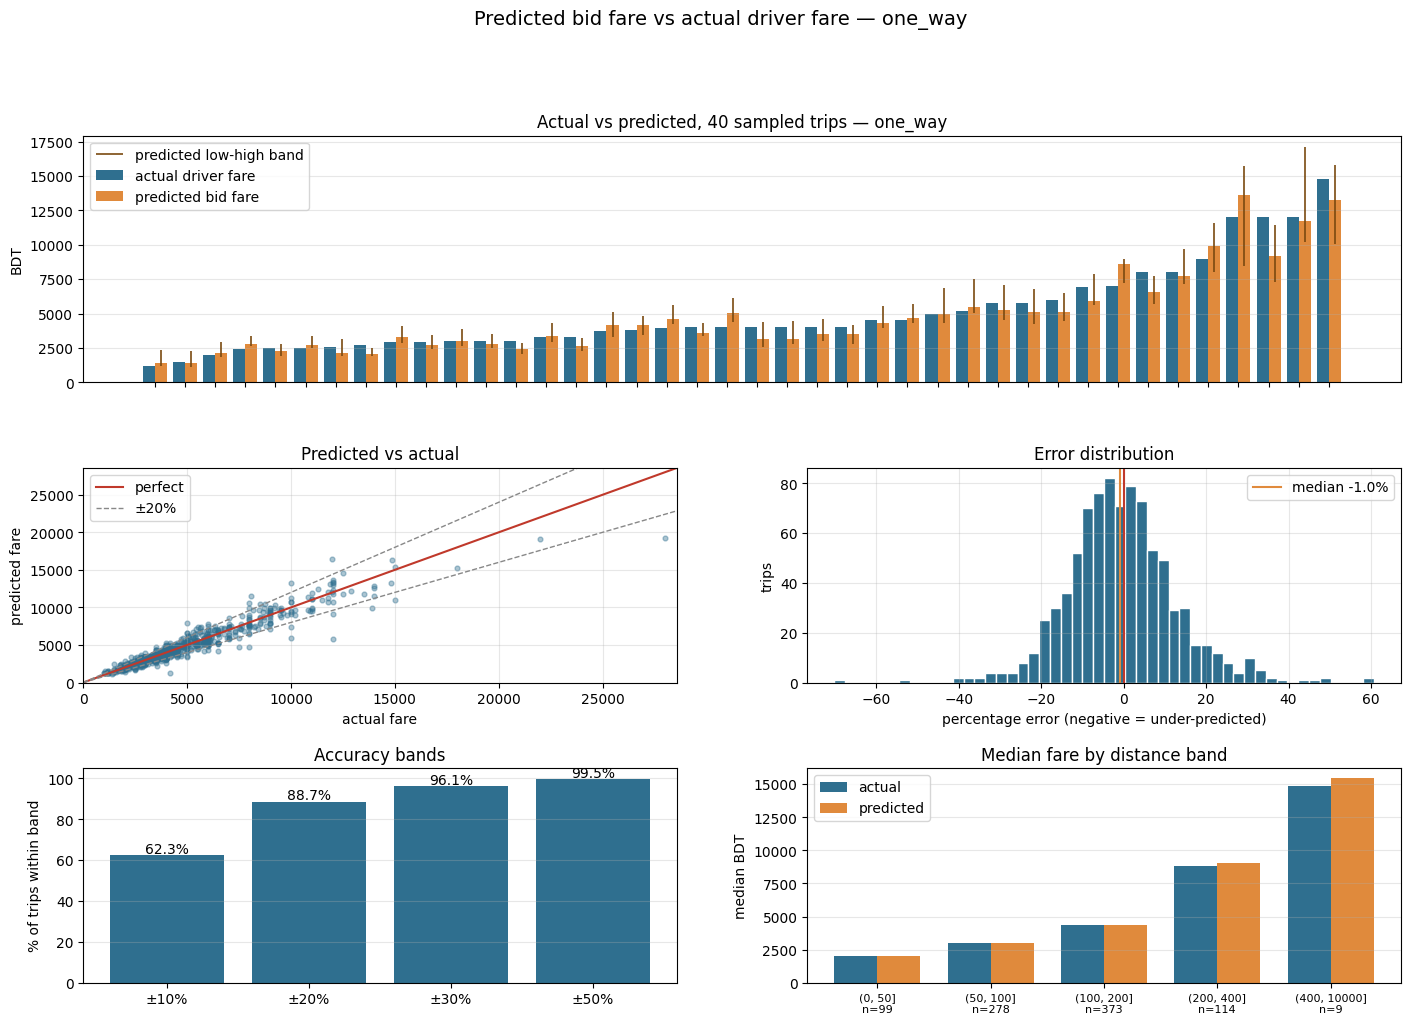

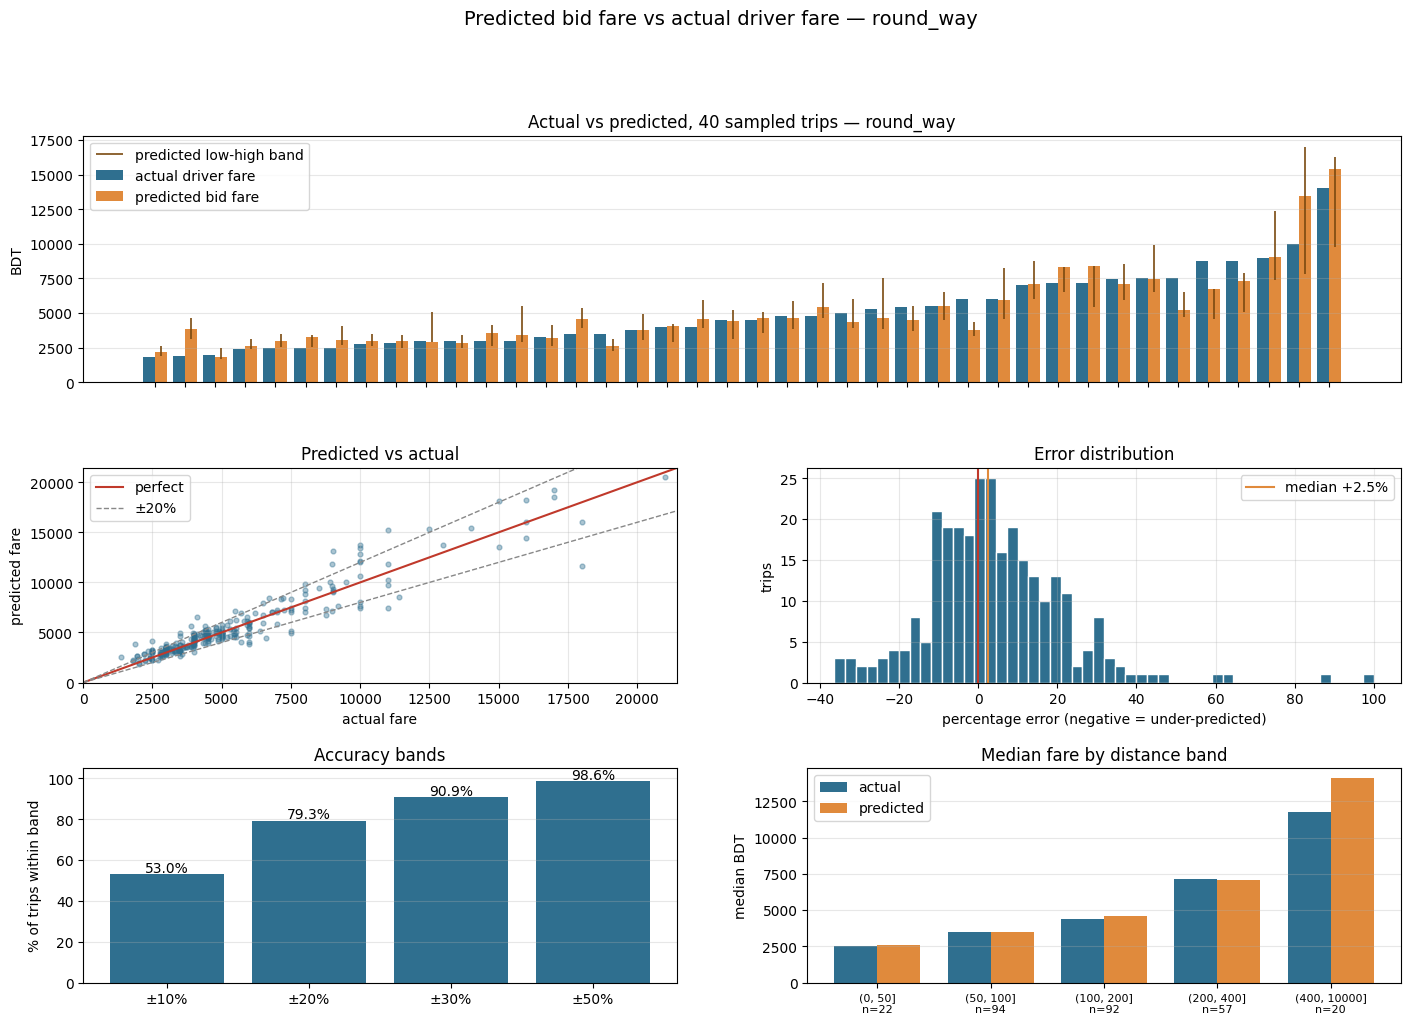

In [ ]:
NEW_FILE = "/content/drive/MyDrive/recent_trips.csv"

scored = compare_with_actual(
    NEW_FILE, DATA, PREDICTORS,
    export_csv="/content/drive/MyDrive/fare_predictions_scored.csv")

In [ ]:
full_report(scored)          # car type, distance, fuel price, AC status, worst rows

---- by car_type ----
                   n     MAE  MedAE  MAPE%  MedAPE%    R2  within10%  within20%  band_cov%    bias
Sedan Premium  576.0  489.52  290.0  10.58     7.71  0.87      62.85      86.98      84.72  -58.61
Sedan          272.0  366.90  250.0  10.52     8.03  0.88      62.13      87.13      82.72  -51.63
Noah           177.0  700.66  510.0  10.94     9.24  0.90      54.80      87.01      83.62    2.65
HiAce          112.0  971.22  725.0  12.05    10.35  0.86      48.21      79.46      77.68  208.90
Sedan Economy   21.0  376.62  230.0   9.07     6.47  0.90      61.90      90.48      95.24 -127.67

---- by distance band ----
                  n      MAE   MedAE  MAPE%  MedAPE%    R2  within10%  within20%  band_cov%    bias
(100, 200]    465.0   485.73   330.0   9.78     7.21  0.78      63.66      90.11      85.38  -66.48
(50, 100]     372.0   335.84   240.0  10.31     8.00  0.73      60.75      88.17      84.41  -30.77
(200, 400]    171.0   993.66   720.0  11.52     9.75  0.

,ID,Booking ID,Car Type,No Of Seat,Trip Type,Pickup Location,Pickup Lat,Pickup Long,Dropoff Location,Dropoff Lat,...,pred,pred_high,fuel_price,fuel_effect_pct,actual,error,abs_error,pct_error,abs_pct_error,in_band
0,467566,26083134APCR,Sedan Premium,4 Seats,one_way,Dhaka,23.804093,90.415238,"Bogura, Bogra, Rajshahi",24.852554,...,5770.0,7540.0,142.5,6.1,12000.0,-6230.0,6230.0,-51.916667,51.916667,False
1,467654,26090106QSJQ,Sedan Premium,4,one_way,"Akij Ceramics Mosques, Mymensingh",24.481594,90.372562,"Hazrat Shahjalal International Airport (DAC), ...",23.843434,...,2820.0,3550.0,142.5,6.1,3500.0,-680.0,680.0,-19.428571,19.428571,True
2,467659,26090119KHNV,Sedan Premium,4 Seats,one_way,"298 Rd No. 16, Dhaka 1219, Bangladesh",23.755723,90.443664,"Jalalpur Bazar,Pabna,Dhaka, Jalalpur Road, Pab...",24.022849,...,5180.0,7220.0,142.5,6.1,5899.0,-719.0,719.0,-12.188507,12.188507,True
3,467670,26090152VQJK,Sedan,4 Seats,one_way,"Ishwarganj, Mymensingh",24.683996,90.606043,"জাতীয় বিশ্ব্যবিদ্যালয়, Gazipur, Dhaka",23.965210,...,3230.0,4030.0,142.5,5.6,3497.0,-267.0,267.0,-7.635116,7.635116,True
4,467672,26090130JSQY,Sedan Premium,4,one_way,"Mainamati Cantonment General Hospital, Comilla...",23.482368,91.117016,"Banasree, Dhaka",23.761935,...,3190.0,3940.0,142.5,6.1,3500.0,-310.0,310.0,-8.857143,8.857143,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153,478900,26092227AHPI,Sedan Premium,4 Seats,one_way,"Chasara, Narayanganj, Dhaka",23.626361,90.499207,"Tilagaon Eco Village, Bhanugach, Moulvi, Sylhet",24.321172,...,6180.0,7670.0,162.5,11.4,5025.0,1155.0,1155.0,22.985075,22.985075,False
1154,478902,26092242BONC,Sedan,4 Seats,one_way,"Panchariya Bus Stop, 4367, Chittagong, Chattogram",22.326940,91.915271,"Pekua Upazila, Cox's, Chattogram",21.832736,...,3440.0,4460.0,162.5,10.5,2324.0,1116.0,1116.0,48.020654,48.020654,False
1155,478906,26092209RFHJ,Sedan,4 Seats,one_way,"Kachua Government Pilot High School, Kachua Rd...",23.346986,90.898694,"Sector 10, Road Number 12, Uttara, Dhaka",23.872812,...,3380.0,4020.0,162.5,10.5,2987.0,393.0,393.0,13.157014,13.157014,True
1156,478919,26092207JWMQ,Sedan Premium,4 Seats,round_way,"Nangalkot, Comilla, Chattogram",23.162696,91.203295,"The Palace Luxury Resort, Putijuri, Habiganj, ...",24.402762,...,13510.0,17410.0,162.5,12.3,15000.0,-1490.0,1490.0,-9.933333,9.933333,True


## 8 · Stage G — management report

Evidence behind predictions, grouped drivers, correlation, accuracy, fuel
history and a per-quote waterfall (with an explicit fuel step).

In [ ]:
"""
STAGE G — Evidence & explainability report (management view).

Answers two questions in plain terms:

  1. WHAT DATA BACKS A PREDICTION?
     How many real historical trips sit behind a typical quote, and which ones.
  2. WHAT MOVES THE FARE?
     Correlation, overall model reliance, and a per-quote breakdown.

Honesty note carried into the charts: the shipped number is a 4-model blend
(CatBoost ~0.50, LightGBM-rate ~0.31, LightGBM-L1 ~0.11, linear ~0.06).
Feature attribution is computed from the LightGBM component, so it shows which
drivers matter and roughly how much -- it is not an exact decomposition of the
blended output. Every attribution chart says so on its face.
"""
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130,
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

INK = "#10201B"
BLUE = "#2F6F8F"
AMBER = "#E39B29"
GREEN = "#0B6E4F"
RED = "#A03828"
MUTED = "#6B7772"

# ---------------------------------------------------------------- grouping
# 95 raw feature names mean nothing to management. These groups do.
GROUPS = [
    ("Distance", lambda c: c in {"total_km", "log_km", "hav_km", "road_factor"}),
    ("Route history (learned from past trips)", lambda c: c.startswith("enc_")),
    ("Toll roads / ferry crossings",
     lambda c: c.startswith("crosses_") or c in {
         "n_barriers", "est_toll_bdt", "toll_per_km", "log_toll", "same_region"}),
    ("Festival timing (Eid)",
     lambda c: c.startswith("eid_") or c.startswith("d2") or c.startswith("abs_d2")
     or c in {"is_adha", "adha_rush", "festival_week"}),
    ("Trip duration (round trips)",
     lambda c: c in {"round_hours", "km_per_day", "km_per_hour", "is_multiday"}),
    ("Vehicle", lambda c: c in {"car_type", "seats", "car_year"}),
    ("Where the trip goes (geography)",
     lambda c: c in {
         "pickup_lat", "pickup_long", "dropoff_lat", "dropoff_long", "bearing",
         "lat_delta", "long_delta", "same_district", "same_division",
         "do_dist_dhaka", "pu_dist_dhaka", "net_toward_dhaka", "to_dhaka",
         "from_dhaka", "do_origin_share", "do_term_share", "log_backhaul_ratio",
         "pickup_division", "pickup_district", "dropoff_division",
         "dropoff_district", "pu_zone", "do_zone", "zone_pair", "route_und",
         "region_pair"}),
    ("Booking timing (hour, day, lead time)",
     lambda c: c in {
         "hour", "dow", "month", "is_weekend", "is_night", "hour_sin", "hour_cos",
         "dow_sin", "dow_cos", "month_sin", "month_cos", "lead_hours",
         "log_lead_hours", "is_same_day"}),
]

# plain-language names for the raw features that show up most
PRETTY = {
    "total_km": "Trip distance", "log_km": "Trip distance (log)",
    "hav_km": "Straight-line distance", "road_factor": "Road vs straight-line ratio",
    "round_hours": "Trip duration", "km_per_day": "Km per day",
    "km_per_hour": "Km per hour", "is_multiday": "Multi-day trip",
    "seats": "Seats", "car_type": "Car type", "car_year": "Car model year",
    "log_toll": "Estimated toll", "est_toll_bdt": "Estimated toll (BDT)",
    "toll_per_km": "Toll per km", "crosses_padma": "Crosses Padma bridge",
    "crosses_jamuna": "Crosses Jamuna bridge", "n_barriers": "Toll barriers crossed",
    "fuel_price": "Fuel price at booking",
    "d2eid": "Days from Eid", "abs_d2eid": "Days from Eid (absolute)",
    "eid_rush": "Eid rush window", "eid_peak": "Eid peak (3 days before)",
    "eid_week": "Eid week", "eid_return": "Eid return window",
    "eid_extended": "Near Eid (2 weeks)", "eid_lull": "Pre-Eid lull",
    "is_adha": "Eid al-Adha (vs Fitr)", "adha_rush": "Eid al-Adha rush",
    "d2festival": "Days from nearest festival",
    "abs_d2festival": "Days from festival (absolute)",
    "festival_week": "Festival week",
    "do_origin_share": "How often trips start at the destination",
    "do_term_share": "How often trips end at the destination",
    "crosses_meghna": "Crosses Meghna bridge",
    "crosses_sylhet": "Crosses Sylhet toll road",
    "same_region": "Within one region", "region_pair": "Region pair",
    "bearing": "Direction of travel", "dow": "Day of week",
    "month": "Month", "pu_zone": "Pickup zone", "do_zone": "Dropoff zone",
    "pickup_division": "Pickup division", "dropoff_division": "Dropoff division",
    "lat_delta": "North-south shift", "long_delta": "East-west shift",
    "lead_hours": "Booked this far ahead", "log_lead_hours": "Booking lead time",
    "is_same_day": "Same-day booking", "is_night": "Night pickup",
    "is_weekend": "Weekend", "hour": "Pickup hour",
    "same_district": "Within one district", "same_division": "Within one division",
    "do_dist_dhaka": "Dropoff distance from Dhaka",
    "pu_dist_dhaka": "Pickup distance from Dhaka",
    "net_toward_dhaka": "Direction relative to Dhaka",
    "log_backhaul_ratio": "Return-load availability",
    "dropoff_district": "Dropoff district", "pickup_district": "Pickup district",
    "zone_pair": "Route (zone to zone)", "route_und": "Route",
}


def pretty(col):
    if col in PRETTY:
        return PRETTY[col]
    if col.startswith("enc_"):
        return "Past fares on this route"
    return col.replace("_", " ").capitalize()


def group_of(col):
    for name, test in GROUPS:
        if test(col):
            return name
    return "Other"


def _bdt(ax, axis="y"):
    f = FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)


# ================================================================= SECTION 1
def evidence_report(DATA, tt, verbose=True):
    """How many real trips sit behind a typical quote."""
    data = DATA[tt]
    tbl = data["enc"].maps_["enc_dist_pair_car"]
    n_corr = np.expm1(tbl["cnt"]).round()

    # support actually seen by held-out quotes (what a live quote will look like)
    out = {}
    for split in ("test",):
        sp = data[split]
        idx = pd.MultiIndex.from_frame(
            sp[["pickup_district", "dropoff_district", "car_type"]])
        s = np.expm1(tbl["cnt"].reindex(idx).fillna(0.0)).round()
        out[split] = s.to_numpy()

    sup = out["test"]
    stats = {
        "training trips": len(data["train"]),
        "distinct routes (district pair x car)": len(tbl),
        "median trips behind a quote": float(np.median(sup)),
        "quotes backed by 20+ trips": float((sup >= 20).mean() * 100),
        "quotes backed by 5+ trips": float((sup >= 5).mean() * 100),
        "quotes with no exact-route history": float((sup == 0).mean() * 100),
    }
    if verbose:
        print(f"--- {tt}: evidence behind a prediction ---")
        for k, v in stats.items():
            print(f"   {k:<42} {v:,.1f}" if isinstance(v, float)
                  else f"   {k:<42} {v:,}")
    return stats, sup, n_corr


def plot_evidence(DATA, tt, save=None):
    stats, sup, n_corr = evidence_report(DATA, tt, verbose=False)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

    bins = [0, 1, 5, 20, 50, 100, 10 ** 9]
    labels = ["none", "1-4", "5-19", "20-49", "50-99", "100+"]
    cnt = pd.cut(pd.Series(sup), bins=bins, right=False, labels=labels).value_counts()[labels]
    share = cnt / cnt.sum() * 100
    bars = ax[0].bar(labels, share, color=[RED, AMBER, AMBER, GREEN, GREEN, GREEN])
    for b, v in zip(bars, share):
        ax[0].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center",
                   fontsize=9)
    ax[0].set_title("How many past trips back a quote", fontweight="bold")
    ax[0].set_ylabel("% of quotes")
    ax[0].set_xlabel("comparable trips on the same route + car type")
    ax[0].set_ylim(0, max(share) * 1.2)

    tr = DATA[tt]["train"]
    by_car = tr["car_type"].value_counts()
    ax[1].barh(by_car.index[::-1], by_car.values[::-1], color=BLUE)
    for i, v in enumerate(by_car.values[::-1]):
        ax[1].text(v + max(by_car) * .01, i, f"{v:,}", va="center", fontsize=9)
    ax[1].set_title("Training trips by vehicle", fontweight="bold")
    ax[1].set_xlabel("trips")
    _bdt(ax[1], "x")
    ax[1].set_xlim(0, max(by_car) * 1.18)

    months = tr["created_dt"].dt.to_period("M").value_counts().sort_index()
    ax[2].bar([str(p) for p in months.index], months.values, color=BLUE)
    ax[2].set_title("Training trips over time", fontweight="bold")
    ax[2].set_ylabel("trips")
    step = max(1, len(months) // 8)
    ax[2].set_xticks(range(0, len(months), step))
    ax[2].set_xticklabels([str(months.index[i]) for i in range(0, len(months), step)],
                          rotation=45, ha="right", fontsize=8)

    fig.suptitle(f"What the {tt.replace('_', ' ')} model learned from  —  "
                 f"{len(tr):,} completed trips",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()
    return stats


def comparable_trips(DATA, tt, pickup_district, dropoff_district, car_type, n=12):
    """The actual historical rows behind a given route + vehicle."""
    tr = DATA[tt]["train"]
    m = ((tr["pickup_district"] == pickup_district)
         & (tr["dropoff_district"] == dropoff_district)
         & (tr["car_type"] == car_type))
    cols = ["created_dt", "pickup_dt", "total_km", "y", "fpk"]
    d = tr.loc[m, cols].copy()
    d.columns = ["booked", "pickup", "km", "driver_fare", "fare_per_km"]
    d = d.sort_values("pickup", ascending=False)
    print(f"{len(d):,} comparable trips: {pickup_district} -> {dropoff_district}, "
          f"{car_type} ({tt.replace('_',' ')})")
    if len(d):
        print(f"   fare range {d['driver_fare'].min():,.0f} - "
              f"{d['driver_fare'].max():,.0f} BDT  |  median "
              f"{d['driver_fare'].median():,.0f}  |  median {d['fare_per_km'].median():.1f} BDT/km")
    return d.head(n).round(1)


def plot_comparables(DATA, tt, pickup_district, dropoff_district, car_type,
                     quote=None, save=None):
    """Distribution of real past fares, with the quote drawn over it."""
    tr = DATA[tt]["train"]
    m = ((tr["pickup_district"] == pickup_district)
         & (tr["dropoff_district"] == dropoff_district)
         & (tr["car_type"] == car_type))
    d = tr.loc[m]
    if not len(d):
        print("no comparable trips for that combination")
        return
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

    ax[0].hist(d["y"], bins=min(30, max(6, len(d) // 6)), color=BLUE,
               edgecolor="white")
    if quote:
        ax[0].axvspan(quote["low"], quote["high"], color=AMBER, alpha=.22,
                      label=f"predicted range {quote['low']:,.0f}-{quote['high']:,.0f}")
        ax[0].axvline(quote["typical"], color=RED, lw=2,
                      label=f"suggested bid {quote['typical']:,.0f}")
    ax[0].axvline(d["y"].median(), color=GREEN, lw=2, ls="--",
                  label=f"historical median {d['y'].median():,.0f}")
    ax[0].set_title(f"What this route actually paid  (n={len(d):,})",
                    fontweight="bold")
    ax[0].set_xlabel("driver fare (BDT)")
    ax[0].set_ylabel("trips")
    ax[0].legend(fontsize=8)
    _bdt(ax[0], "x")

    ax[1].scatter(d["total_km"], d["y"], s=22, alpha=.55, color=BLUE,
                  label="past trips")
    if quote:
        ax[1].errorbar([quote["total_km"]], [quote["typical"]],
                       yerr=[[quote["typical"] - quote["low"]],
                             [quote["high"] - quote["typical"]]],
                       fmt="o", color=RED, capsize=5, ms=9, lw=2,
                       label="this quote")
    ax[1].set_title("Fare vs distance on this route", fontweight="bold")
    ax[1].set_xlabel("km")
    ax[1].set_ylabel("driver fare (BDT)")
    ax[1].legend(fontsize=8)
    _bdt(ax[1])

    fig.suptitle(f"{pickup_district} to {dropoff_district}  ·  {car_type}",
                 fontsize=12.5, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()


# ================================================================= SECTION 2
def driver_report(DATA, RESULTS, tt, top=14, save=None):
    """What the model relies on, grouped into business categories."""
    m = RESULTS[tt]["fitted"]["lgbm_l1"]
    imp = pd.Series(m.feature_importances_, index=m.feature_name_, dtype=float)
    imp = imp / imp.sum() * 100

    g = imp.groupby(imp.index.map(group_of)).sum().sort_values(ascending=False)
    g = g[g > 0]

    ind = imp.sort_values(ascending=False).head(top)
    ind.index = [pretty(c) for c in ind.index]
    ind = ind.groupby(level=0).sum().sort_values(ascending=False)

    fig, ax = plt.subplots(1, 2, figsize=(16, max(4.6, 0.42 * len(ind) + 1.6)))

    colors = [GREEN if v >= 15 else BLUE if v >= 5 else MUTED for v in g.values]
    ax[0].barh(g.index[::-1], g.values[::-1], color=colors[::-1])
    for i, v in enumerate(g.values[::-1]):
        ax[0].text(v + .4, i, f"{v:.0f}%", va="center", fontsize=9.5,
                   fontweight="bold")
    ax[0].set_title("What drives the predicted fare", fontweight="bold", fontsize=12)
    ax[0].set_xlabel("share of the model's decision-making (%)")
    ax[0].set_xlim(0, max(g.values) * 1.16)

    ax[1].barh(ind.index[::-1], ind.values[::-1], color=BLUE)
    for i, v in enumerate(ind.values[::-1]):
        ax[1].text(v + .1, i, f"{v:.1f}%", va="center", fontsize=8.5)
    ax[1].set_title(f"Top {len(ind)} individual factors", fontweight="bold",
                    fontsize=12)
    ax[1].set_xlabel("share (%)")
    ax[1].set_xlim(0, max(ind.values) * 1.18)

    fig.suptitle(f"{tt.replace('_', ' ').title()}  ·  drivers of the fare "
                 f"prediction", fontsize=13, fontweight="bold", y=1.02)
    fig.text(0.5, -0.03,
             "Measured on the LightGBM component of the 4-model blend — shows "
             "which factors matter, not an exact split of the final number.",
             ha="center", fontsize=8.5, color=MUTED, style="italic")
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()
    return g.round(1), ind.round(2)


def correlation_report(DATA, tt, top=14, save=None):
    """Plain correlation with fare, for the features a human can interpret."""
    d = DATA[tt]["train"]
    cols = [c for c in DATA[tt]["num"]
            if c in d.columns and not c.startswith("enc_")]
    ylog = d["log_y"].astype(float)
    rows = []
    for c in cols:
        s = d[c].astype(float)
        ok = s.notna()
        if ok.sum() < 50 or s[ok].nunique() < 2:
            continue
        rows.append((c, s[ok].corr(ylog[ok], method="spearman")))
    cor = (pd.DataFrame(rows, columns=["feature", "rho"])
           .assign(absr=lambda x: x["rho"].abs())
           .sort_values("absr", ascending=False).head(top))
    cor["label"] = [pretty(c) for c in cor["feature"]]

    fig, ax = plt.subplots(figsize=(9, max(4, .42 * len(cor) + 1.2)))
    colors = [RED if v < 0 else BLUE for v in cor["rho"]]
    ax.barh(cor["label"][::-1], cor["rho"][::-1], color=colors[::-1])
    for i, v in enumerate(cor["rho"][::-1]):
        ax.text(v + (.015 if v >= 0 else -.015), i, f"{v:+.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=9)
    ax.axvline(0, color=INK, lw=.9)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel("correlation with fare   (+1 raises fare, -1 lowers it)")
    ax.set_title(f"{tt.replace('_', ' ').title()} · what moves with the fare",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()
    return cor[["label", "rho"]].round(3)


# ================================================================= SECTION 3
def explain_quote(DATA, RESULTS, tt, row_index=0, split="test", top=10, save=None):
    """
    Why this specific fare. Uses LightGBM's native SHAP contributions
    (pred_contrib), so no extra library and no extra training.

    Contributions are additive in LOG space; the waterfall converts them to BDT
    cumulatively so the bars sum exactly to the shown prediction.
    """
    data, res = DATA[tt], RESULTS[tt]
    num, cat = res["num"], res["cat"]
    sp = data[split].iloc[[row_index]]
    trX = as_gbm(data["train"], num, cat)
    X = align_categories(trX, as_gbm(sp, num, cat), cat)

    m = res["fitted"]["lgbm_l1"]
    contrib = m.predict(X, pred_contrib=True)[0]
    names = list(m.feature_name_)
    base_log, vals = contrib[-1], contrib[:-1]

    s = pd.Series(vals, index=names)
    s = s.groupby(s.index.map(lambda c: pretty(c))).sum()
    s = s.reindex(s.abs().sort_values(ascending=False).index)
    head, tail = s.head(top), s.iloc[top:]
    if len(tail):
        head = pd.concat([head, pd.Series({"Everything else": tail.sum()})])

    # cumulative log -> BDT so the bars reconcile exactly
    running, steps = base_log, []
    for name, v in head.items():
        new = running + v
        steps.append((name, float(np.expm1(new) - np.expm1(running))))
        running = new
    # fuel is applied OUTSIDE the model (multiplicative, see FuelAdjuster),
    # so it is its own step, and the bars still reconcile to the prediction
    fadj = float(sp["fuel_adj"].iloc[0]) if "fuel_adj" in sp else 0.0
    if abs(fadj) > 1e-9:
        fp = float(sp["fuel_price"].iloc[0])
        ref = data["fuel"].ref if data.get("fuel") is not None else fp
        steps.append((f"Fuel price Tk {fp:.0f} vs Tk {ref:.0f}",
                      float(np.expm1(running + fadj) - np.expm1(running))))
        running += fadj
    final_pred = float(np.expm1(running))
    base_bdt = float(np.expm1(base_log))

    actual = float(sp["y"].iloc[0])
    fig, ax = plt.subplots(figsize=(11, max(4.4, .46 * len(steps) + 2.4)))
    y, left = np.arange(len(steps) + 2)[::-1], base_bdt
    ax.barh(y[0], base_bdt, color=MUTED)
    ax.text(base_bdt * .5, y[0], f"typical trip  {base_bdt:,.0f}", va="center",
            ha="center", color="white", fontsize=9, fontweight="bold")
    for i, (name, delta) in enumerate(steps, start=1):
        color = GREEN if delta >= 0 else RED
        ax.barh(y[i], delta, left=left, color=color)
        ax.text(left + delta + (60 if delta >= 0 else -60), y[i],
                f"{delta:+,.0f}", va="center",
                ha="left" if delta >= 0 else "right", fontsize=9)
        left += delta
    ax.barh(y[-1], final_pred, color=BLUE)
    ax.text(final_pred * .5, y[-1], f"predicted  {final_pred:,.0f}", va="center",
            ha="center", color="white", fontsize=9.5, fontweight="bold")

    ax.set_yticks(y)
    ax.set_yticklabels(["Starting point"] + [n for n, _ in steps] + ["Prediction"],
                       fontsize=9.5)
    ax.axvline(actual, color=INK, ls="--", lw=1.6)
    ax.text(actual, y[0] + .6, f" actual {actual:,.0f}", fontsize=9,
            fontweight="bold")
    ax.set_xlabel("driver fare (BDT)")
    _bdt(ax, "x")

    r = sp.iloc[0]
    ax.set_title(
        f"Why this fare — {r['pickup_district']} to {r['dropoff_district']}, "
        f"{r['car_type']}, {r['total_km']:.0f} km",
        fontweight="bold", fontsize=12.5)
    fig.text(0.5, -0.02,
             "Green raises the fare, red lowers it. Attribution from the "
             "LightGBM component of the 4-model blend — indicative of drivers, "
             "not an exact split of the shipped number.",
             ha="center", fontsize=8.5, color=MUTED, style="italic")
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(steps, columns=["factor", "effect_bdt"]).round(0)


# ================================================================= SECTION 4
def accuracy_report(DATA, RESULTS, tt, save=None):
    """Headline accuracy in management-legible form."""
    data, res = DATA[tt], RESULTS[tt]
    te = data["test"]
    p = predict_point(data, res, te)
    y = te["y"].to_numpy(float)
    ape = np.abs(p - y) / y * 100

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

    ax[0].scatter(y, p, s=10, alpha=.3, color=BLUE)
    lim = [0, max(y.max(), p.max()) * 1.02]
    ax[0].plot(lim, lim, color=RED, lw=1.5, label="perfect")
    ax[0].plot(lim, [v * 1.2 for v in lim], ls="--", color=MUTED, lw=1, label="±20%")
    ax[0].plot(lim, [v * .8 for v in lim], ls="--", color=MUTED, lw=1)
    ax[0].set_xlim(lim); ax[0].set_ylim(lim)
    ax[0].set_xlabel("actual fare"); ax[0].set_ylabel("predicted fare")
    ax[0].set_title("Predicted vs actual", fontweight="bold")
    ax[0].legend(fontsize=8)
    _bdt(ax[0]); _bdt(ax[0], "x")

    bands = [10, 20, 30]
    vals = [float((ape <= b).mean() * 100) for b in bands]
    bars = ax[1].bar([f"within ±{b}%" for b in bands], vals,
                     color=[GREEN, GREEN, BLUE])
    for b, v in zip(bars, vals):
        ax[1].text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%",
                   ha="center", fontweight="bold")
    ax[1].set_ylim(0, 108)
    ax[1].set_ylabel("% of trips")
    ax[1].set_title("How close the suggestions land", fontweight="bold")

    d = pd.DataFrame({"km": te["total_km"].to_numpy(), "ape": ape})
    d["band"] = pd.cut(d["km"], [0, 50, 100, 200, 400, 10 ** 9],
                       labels=["0-50", "50-100", "100-200", "200-400", "400+"])
    med = d.groupby("band", observed=True)["ape"].median()
    n = d.groupby("band", observed=True).size()
    ax[2].bar(med.index.astype(str), med.values, color=BLUE)
    for i, (v, c) in enumerate(zip(med.values, n.values)):
        ax[2].text(i, v + .25, f"{v:.1f}%\nn={c}", ha="center", fontsize=8.5)
    ax[2].set_ylabel("median error (%)")
    ax[2].set_xlabel("trip distance (km)")
    ax[2].set_title("Accuracy holds across distance", fontweight="bold")
    ax[2].set_ylim(0, max(med.values) * 1.35)

    fig.suptitle(f"{tt.replace('_', ' ').title()} · accuracy on {len(te):,} "
                 f"trips the model never saw", fontsize=13, fontweight="bold",
                 y=1.03)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()
    return {"median_error_pct": float(np.median(ape)),
            "within10": float((ape <= 10).mean() * 100),
            "within20": float((ape <= 20).mean() * 100)}


def fuel_report(DATA, tt, save=None):
    """Pump price vs fare per km over time, raw and fuel-adjusted."""
    frames = [DATA[tt][s] for s in ("train", "calib", "test")]
    d = pd.concat(frames)
    t = fuel_audit(d)
    if not len(t):
        print("not enough data"); return None
    x = np.arange(len(t))
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.plot(x, t["raw_fpk"], marker="o", color=BLUE, label="fare per km (as paid)")
    if "adjusted_fpk" in t:
        ax.plot(x, t["adjusted_fpk"], marker="o", color=GREEN, ls="--",
                label="fare per km (fuel-adjusted)")
    ax.set_ylabel("median BDT per km")
    ax2 = ax.twinx()
    ax2.step(x, t["fuel_price"], where="mid", color=AMBER, lw=2.2,
             label="pump price (Tk/L)")
    ax2.set_ylabel("Tk per litre", color=AMBER)
    ax2.grid(False)
    ax.set_xticks(x)
    ax.set_xticklabels([str(p) for p in t.index], rotation=45, ha="right", fontsize=8)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="upper left")
    ax.set_title(f"{tt.replace('_', ' ').title()} · fuel price vs fare per km",
                 fontweight="bold", fontsize=12)
    fig.text(0.5, -0.04,
             "Monthly medians are shaped by trip mix (more long trips = lower Tk/km), "
             "so read this as context. The mix-controlled test is compare_fuel_strategies(). "
             "Months before the first fuel-table row use that first price.",
             ha="center", fontsize=8.5, color=MUTED, style="italic")
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()
    return t


def full_report_g(DATA, RESULTS, trip_types=("one_way", "round_way")):
    for tt in trip_types:
        print("=" * 78)
        print(f"  {tt.replace('_', ' ').upper()}")
        print("=" * 78)
        evidence_report(DATA, tt)
        plot_evidence(DATA, tt)
        driver_report(DATA, RESULTS, tt)
        correlation_report(DATA, tt)
        accuracy_report(DATA, RESULTS, tt)
        fuel_report(DATA, tt)
        explain_quote(DATA, RESULTS, tt, row_index=0)
        print()


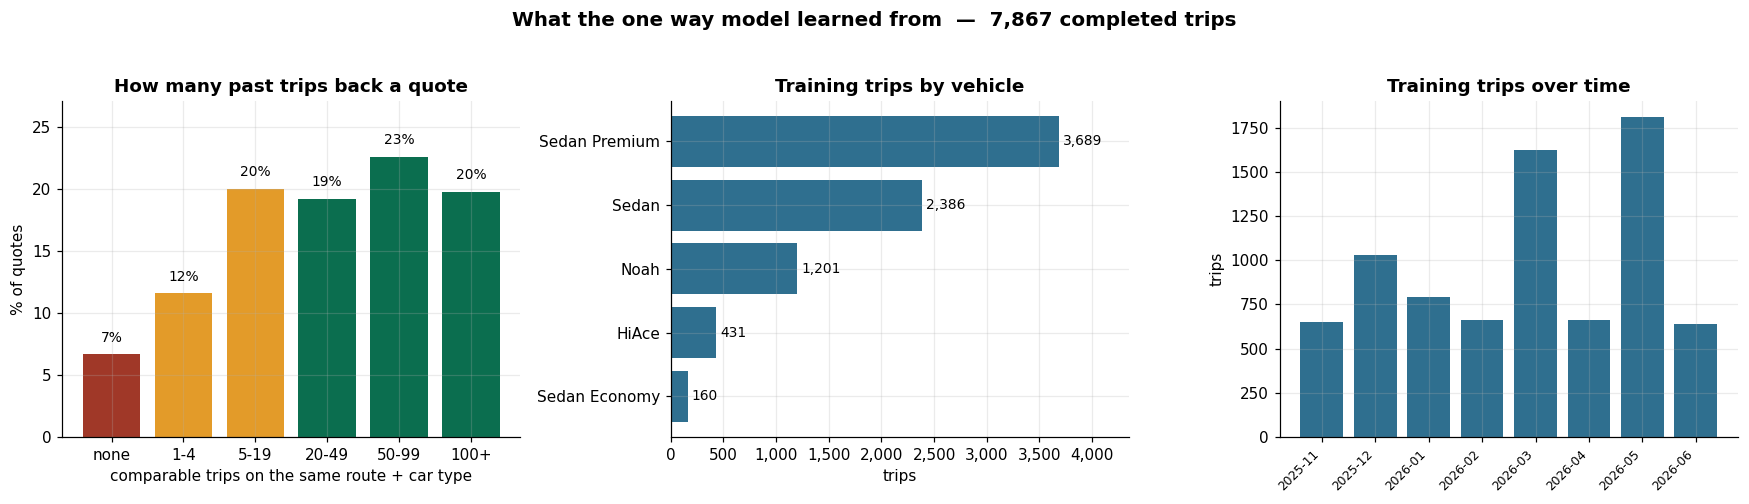

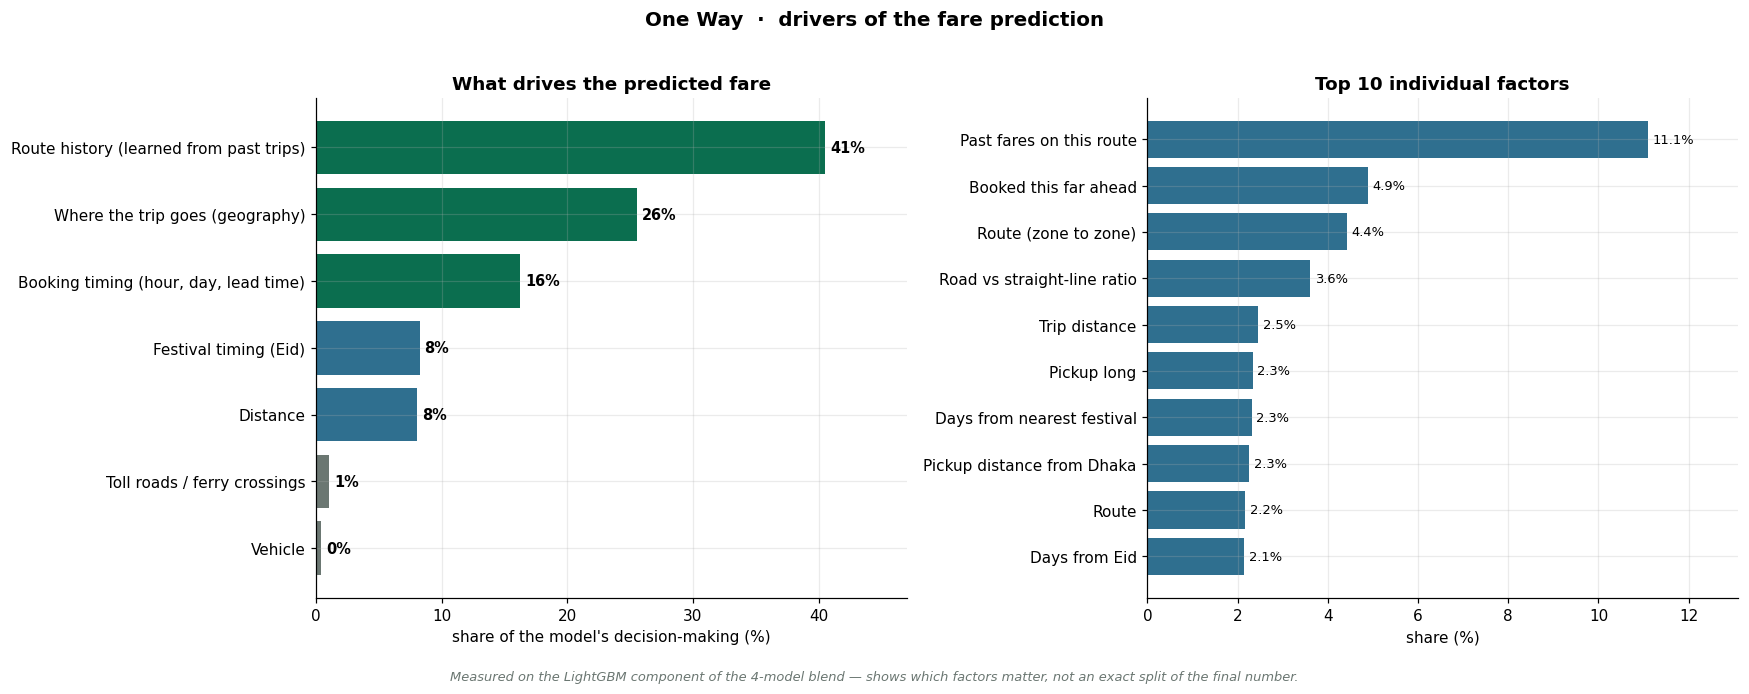

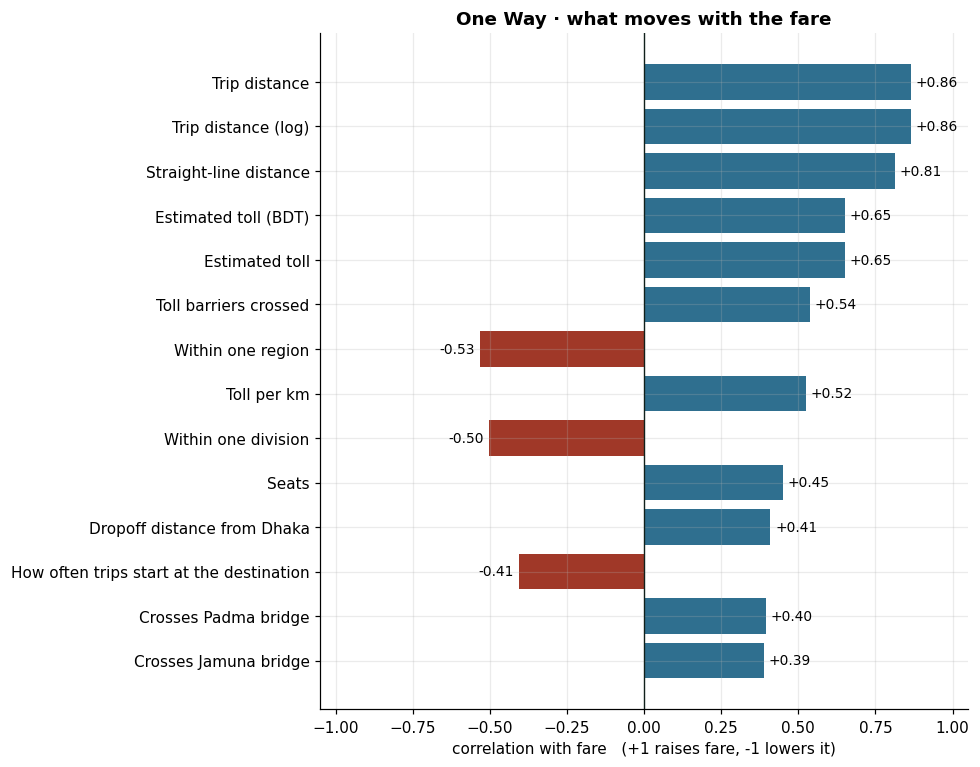

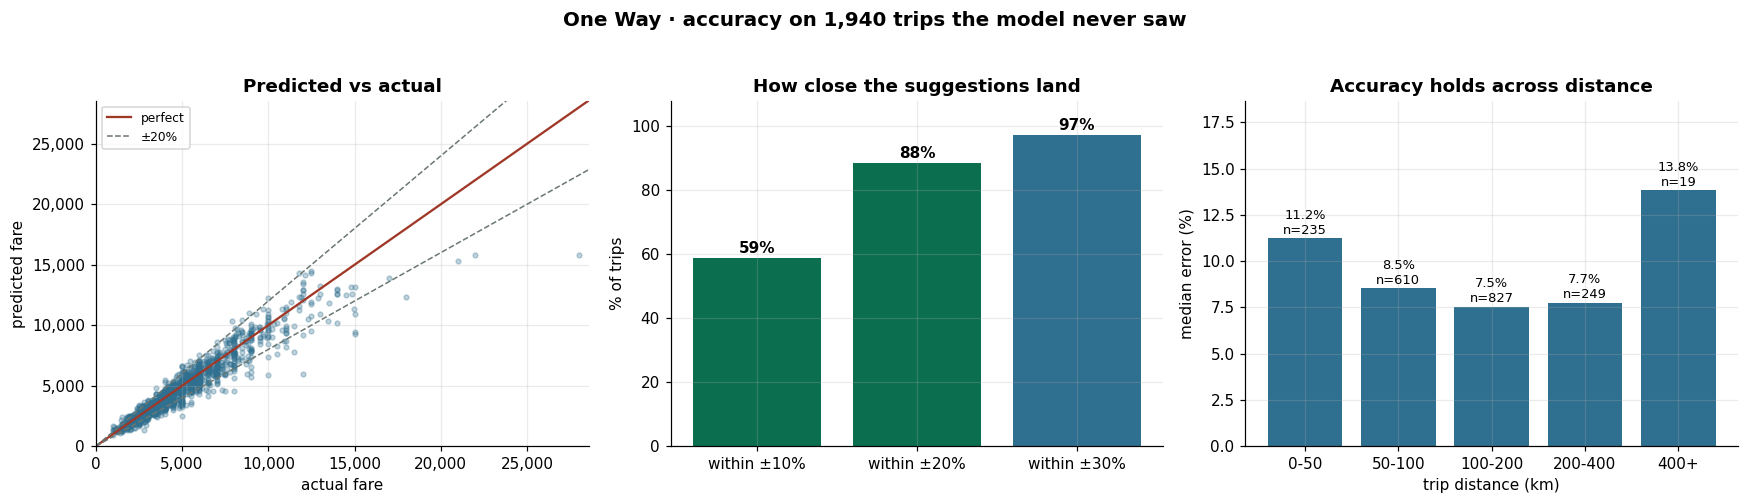

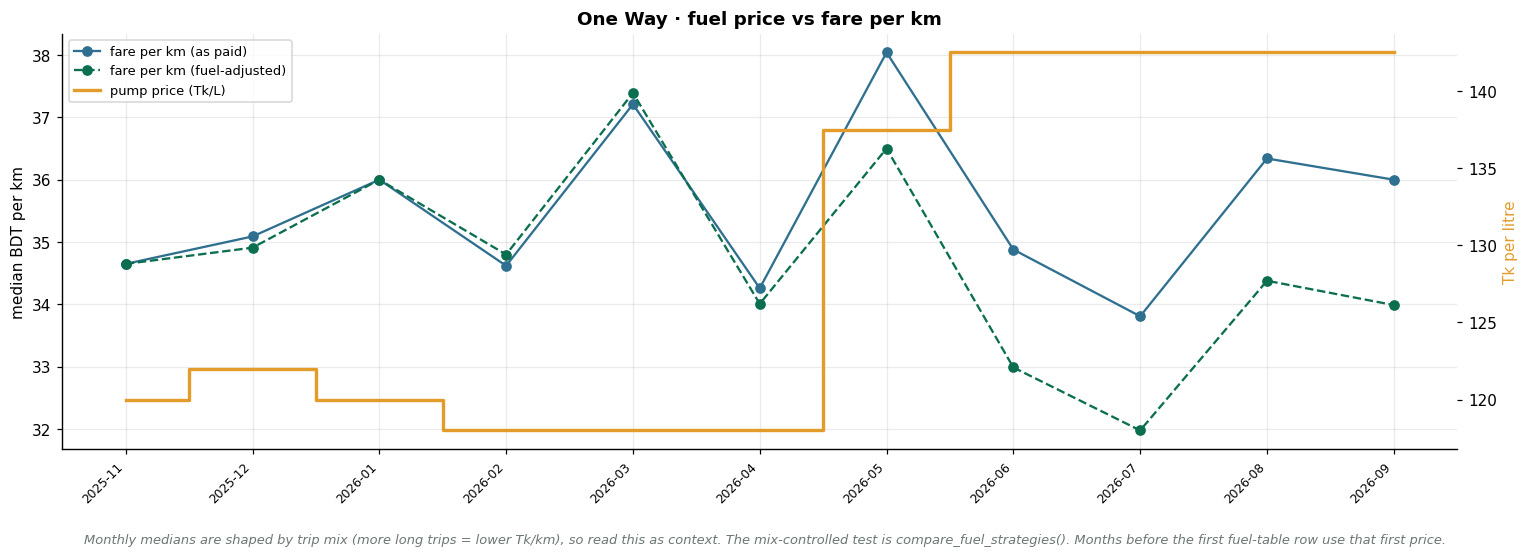

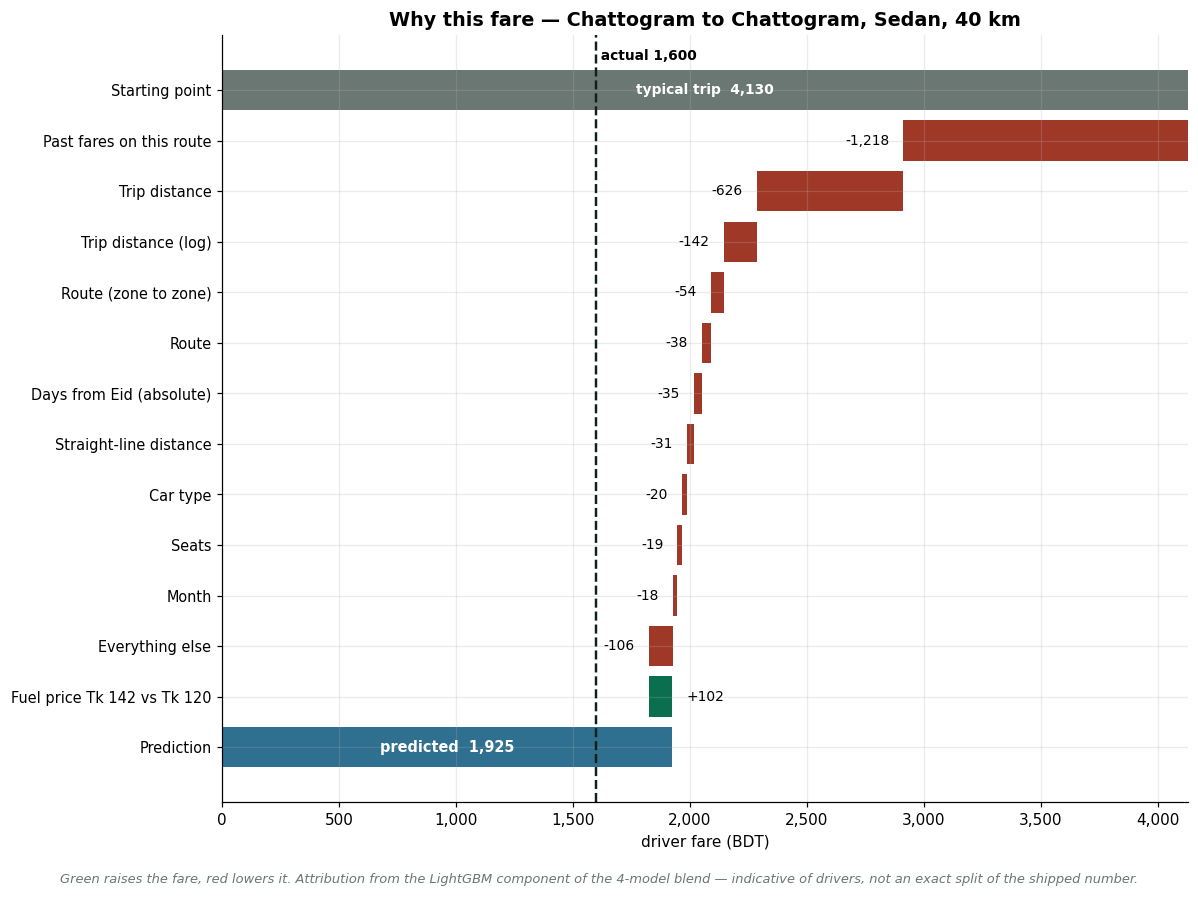

,factor,effect_bdt
0,Past fares on this route,-1218.0
1,Trip distance,-626.0
2,Trip distance (log),-142.0
3,Route (zone to zone),-54.0
4,Route,-38.0
5,Days from Eid (absolute),-35.0
6,Straight-line distance,-31.0
7,Car type,-20.0
8,Seats,-19.0
9,Month,-18.0


In [ ]:
tt = "one_way"
plot_evidence(DATA, tt)
driver_report(DATA, RESULTS, tt)
correlation_report(DATA, tt)
accuracy_report(DATA, RESULTS, tt)
fuel_report(DATA, tt)
explain_quote(DATA, RESULTS, tt, row_index=3)

10 comparable trips: Dhaka -> Chattogram, Sedan (one way)
   fare range 2,700 - 6,725 BDT  |  median 4,900  |  median 30.4 BDT/km
                  booked              pickup   km  driver_fare  fare_per_km
7910 2026-05-27 09:01:00 2026-05-27 11:15:00  126       4800.0         38.1
7479 2026-05-23 12:59:00 2026-05-27 06:00:00   91       4000.0         44.0
7404 2026-05-22 20:05:00 2026-05-23 15:00:00   90       3399.0         37.8
5929 2026-04-15 14:29:00 2026-04-15 19:30:00  102       3600.0         35.3
5468 2026-03-30 10:19:00 2026-03-30 12:00:00  263       6725.0         25.6
3803 2026-03-04 08:58:00 2026-03-19 07:00:00  252       6450.0         25.6
4648 2026-03-17 12:18:00 2026-03-18 08:30:00   68       2700.0         39.7
4183 2026-03-11 22:23:00 2026-03-17 06:00:00  251       6000.0         23.9
3931 2026-03-07 11:46:00 2026-03-16 15:00:00  209       4999.0         23.9
2899 2026-01-31 10:45:00 2026-01-31 13:00:00  231       5700.0         24.7


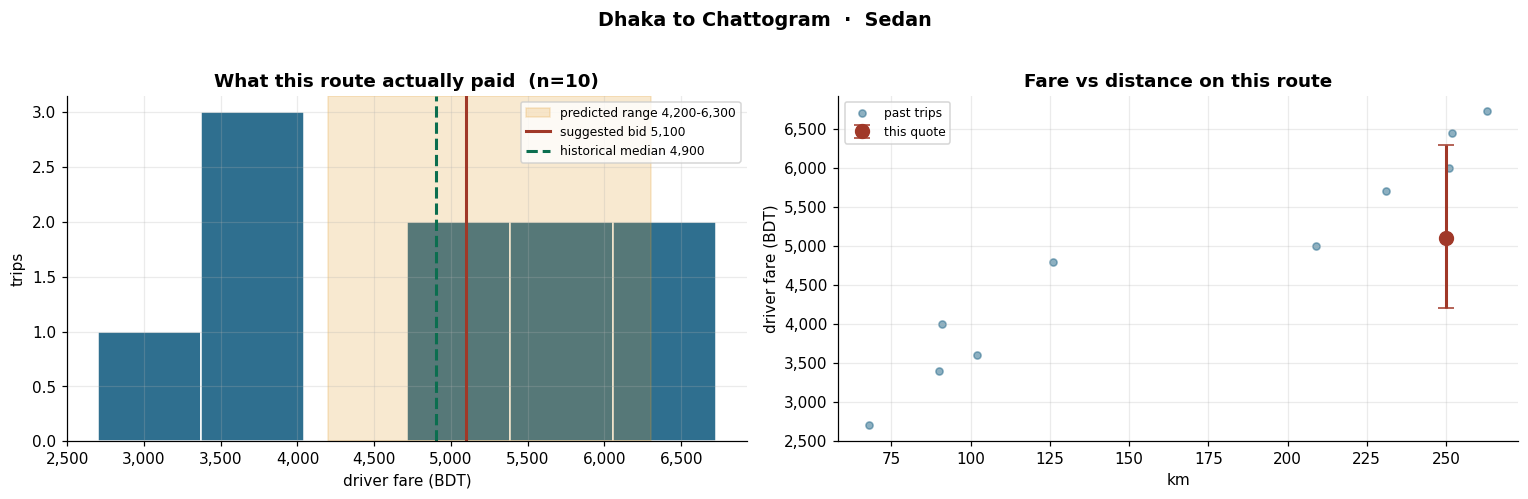

In [ ]:
# the real past trips behind one route, with a quote drawn over them
print(comparable_trips(DATA, "one_way", "Dhaka", "Chattogram", "Sedan"))
plot_comparables(DATA, "one_way", "Dhaka", "Chattogram", "Sedan",
                 quote={"low": 4200, "typical": 5100, "high": 6300, "total_km": 250})

## 9 · Export for the localhost app

Writes **two** files into `OUT_DIR`. Copy both into the app folder:

* `bid_model_bundle.pkl`
* `requirements.txt` — exact library versions of this session, with the
  required Python version written at the top. Use it to build the app's venv.

It also prints the Python version. The app refuses to start on a different
Python minor version (that mismatch caused the earlier `SystemError`).

In [ ]:
"""
EXPORT — writes the bundle the localhost app loads, plus a pinned
requirements file. Run as the LAST cell, after PREDICTORS exists.

  * bid_model_bundle.pkl  models + calibration tables + fuel settings + versions
  * requirements.txt      exact library versions of THIS Colab session

Copy BOTH into the app folder. The app refuses to start (with a clear message)
if your local Python or scikit-learn does not match what is recorded here --
that mismatch is what caused `_RemainderColsList` and
`SystemError: no locals when deleting 'dict'` before.

Confidence calibration uses two sources on purpose:
  * route support counts  -> the TRAINING set
  * hit rates             -> calibration + test slices only (never fitted on);
                             scoring training rows would overstate confidence
"""
import os, sys, platform
import cloudpickle
import sklearn, lightgbm

OUT_DIR = "/content/drive/MyDrive/bid_app_export"      # change if needed
os.makedirs(OUT_DIR, exist_ok=True)

SUPPORT_BUCKETS = [(0, 0, "none"), (1, 4, "1-4"), (5, 19, "5-19"), (20, 10 ** 9, "20+")]
WIDTH_BUCKETS = [(0.0, 0.25, "tight"), (0.25, 0.40, "medium"), (0.40, 10.0, "wide")]
KM_BINS = [(0, 50, "0-50"), (50, 100, "50-100"), (100, 200, "100-200"),
           (200, 400, "200-400"), (400, 10 ** 9, "400+")]
HIT_TOL, SHRINK = 0.20, 25


def _bucket(v, buckets):
    for lo, hi, lab in buckets:
        if lo <= v <= hi:
            return lab
    return buckets[-1][2]


def _rate_table(df, key):
    return {str(k): {"n": int(len(g)), "hit": float(g["hit"].mean()),
                     "cov": float(g["in_band"].mean())}
            for k, g in df.groupby(key, observed=True)}


def build_calibration(DATA, RESULTS, verbose=True):
    calib = {}
    for tt in DATA:
        data, res = DATA[tt], RESULTS[tt]
        tbl = data["enc"].maps_["enc_dist_pair_car"]
        parts = []
        for name in ("calib", "test"):
            sp = data[name]
            typical = predict_point(data, res, sp)          # fuel applied
            lo, hi = predict_interval(data, res, sp)        # fuel applied
            typical = np.clip(typical, lo, hi)
            idx = pd.MultiIndex.from_frame(
                sp[["pickup_district", "dropoff_district", "car_type"]])
            sup = np.expm1(tbl["cnt"].reindex(idx).fillna(0.0)).round().to_numpy()
            parts.append(pd.DataFrame({
                "actual": sp["y"].to_numpy(float), "pred": typical, "lo": lo, "hi": hi,
                "car_type": sp["car_type"].to_numpy(),
                "total_km": sp["total_km"].to_numpy(float), "support": sup}))
        d = pd.concat(parts, ignore_index=True)
        d["hit"] = np.abs(d["pred"] - d["actual"]) / d["actual"] <= HIT_TOL
        d["in_band"] = (d["actual"] >= d["lo"]) & (d["actual"] <= d["hi"])
        rel = np.where(d["pred"] > 0, (d["hi"] - d["lo"]) / d["pred"], 1.0)
        d["sup_b"] = [_bucket(v, SUPPORT_BUCKETS) for v in d["support"]]
        d["cell_key"] = [f"{a}|{_bucket(b, WIDTH_BUCKETS)}"
                         for a, b in zip(d["sup_b"], rel)]
        d["km_b"] = [_bucket(v, KM_BINS) for v in d["total_km"]]
        calib[tt] = {
            "n_scored": int(len(d)), "n_train_support": int(len(data["train"])),
            "global_hit": float(d["hit"].mean()), "global_cov": float(d["in_band"].mean()),
            "cell": _rate_table(d, "cell_key"), "by_car": _rate_table(d, "car_type"),
            "by_km": _rate_table(d, "km_b"), "by_support": _rate_table(d, "sup_b"),
            "hit_tol": HIT_TOL, "shrink": SHRINK,
            "support_buckets": [list(b) for b in SUPPORT_BUCKETS],
            "width_buckets": [list(b) for b in WIDTH_BUCKETS],
            "km_bins": [list(b) for b in KM_BINS]}
        if verbose:
            print(f"[{tt}] confidence calibrated on {len(d):,} held-out trips "
                  f"(route support from {len(data['train']):,} training trips) | "
                  f"within-20% {d['hit'].mean():.1%} | band coverage {d['in_band'].mean():.1%}")
    return calib


def _versions():
    v = {"python": f"{sys.version_info.major}.{sys.version_info.minor}",
         "python_full": platform.python_version(),
         "scikit-learn": sklearn.__version__, "lightgbm": lightgbm.__version__,
         "numpy": np.__version__, "pandas": pd.__version__,
         "cloudpickle": cloudpickle.__version__}
    try:
        import catboost; v["catboost"] = catboost.__version__
    except ImportError:
        pass
    try:
        import xgboost; v["xgboost"] = xgboost.__version__
    except ImportError:
        pass
    return v


def export(DATA, RESULTS, PREDICTORS, out_dir=OUT_DIR):
    calibration = build_calibration(DATA, RESULTS)
    meta = {}
    for tt in PREDICTORS:
        tr, te, r = DATA[tt]["train"], DATA[tt]["test"], RESULTS[tt]
        fu = DATA[tt].get("fuel")
        meta[tt] = {
            "selected_model": r["final"],
            "n_train": int(len(tr)), "n_test": int(len(te)),
            "trained_from": str(tr["created_dt"].min().date()),
            "trained_to": str(tr["created_dt"].max().date()),
            # latest booking the model was checked against (held-out test slice);
            # fuel prices up to this date have been validated, not just fitted
            "validated_to": str(te["created_dt"].max().date()),
            "car_types": sorted(tr["car_type"].unique()),
            "seats_by_car": {str(k): int(v) for k, v in
                             tr.groupby("car_type")["seats"].median().items()},
            "metrics": {k: float(v) for k, v in r["report"][f"SELECTED: {r['final']}"].items()},
            "interval": {k: float(v) for k, v in r["interval"].items()},
            "km_p01": float(tr["total_km"].quantile(0.01)),
            "km_p99": float(tr["total_km"].quantile(0.99)),
            "fuel": None if fu is None else fu.describe(),
        }
    versions = _versions()
    bundle = {"predictors": PREDICTORS, "coverage": COVERAGE, "meta": meta,
              "calibration": calibration, "versions": versions,
              "fuel_table": [list(r) for r in FUEL_TABLE],
              "fuel_grade_by_car": dict(FUEL_GRADE_BY_CAR),
              "default_fuel_grade": DEFAULT_FUEL_GRADE}

    pkl = os.path.join(out_dir, "bid_model_bundle.pkl")
    with open(pkl, "wb") as f:
        cloudpickle.dump(bundle, f)

    req = os.path.join(out_dir, "requirements.txt")
    pins = [f"{k}=={versions[k]}" for k in
            ("scikit-learn", "lightgbm", "catboost", "numpy", "pandas", "cloudpickle")
            if k in versions]
    with open(req, "w") as f:
        f.write(f"# generated by the Colab export -- matches the bundle exactly\n"
                f"# create the venv with Python {versions['python']}  "
                f"(e.g.  py -{versions['python']} -m venv .venv)\n"
                "fastapi>=0.116\nuvicorn>=0.34\nhttpx>=0.28\npydantic>=2.12\n"
                + "\n".join(pins) + "\n")

    print(f"\nwritten: {pkl}\nwritten: {req}")
    print(f"built with Python {versions['python_full']}, scikit-learn "
          f"{versions['scikit-learn']} -> your local venv must use Python "
          f"{versions['python']}")
    for tt, m in meta.items():
        print(f"  {tt:10s} {m['selected_model']:8s} SMAPE {m['metrics']['SMAPE%']:.2f}%  "
              f"within20 {m['metrics']['within20%']:.1f}%  trained {m['trained_from']} "
              f"to {m['trained_to']}")
    return pkl


export(DATA, RESULTS, PREDICTORS)


[one_way] confidence calibrated on 3,879 held-out trips (route support from 7,867 training trips) | within-20% 89.3% | band coverage 81.7%
[round_way] confidence calibrated on 1,011 held-out trips (route support from 2,038 training trips) | within-20% 82.1% | band coverage 80.6%

written: /content/drive/MyDrive/bid_app_export/bid_model_bundle.pkl
written: /content/drive/MyDrive/bid_app_export/requirements.txt
built with Python 3.13.15, scikit-learn 1.6.1 -> your local venv must use Python 3.13
  one_way    stack    SMAPE 10.43%  within20 88.4%  trained 2025-11-01 to 2026-06-12
  round_way  stack    SMAPE 11.90%  within20 81.4%  trained 2025-11-01 to 2026-07-01


'/content/drive/MyDrive/bid_app_export/bid_model_bundle.pkl'

In [ ]:
import sys, sklearn, lightgbm, catboost
print("Python", sys.version.split()[0], "| scikit-learn", sklearn.__version__,
      "| lightgbm", lightgbm.__version__, "| catboost", catboost.__version__)

Python 3.13.15 | scikit-learn 1.6.1 | lightgbm 4.6.0 | catboost 1.2.10
